# Can we fit $\mathcal{H}$ Using DNNs at a Single Kinematic Point Using the KM15/BKM10 Formalism for the Cross-Section?

## (1): Initializing Requisite Code/Settings:

### (1.1): Import Libraries:

In [1]:
# native libraries
import glob
import gc

# data analysis
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import corner
from scipy.stats import norm
from sklearn.model_selection import train_test_split

# formalism
import gepard as g
from gepard.fits import th_KM15

# BKM10 library stuff:
from bkm10_lib.core import DifferentialCrossSection
from bkm10_lib.inputs import BKM10Inputs
from bkm10_lib.cff_inputs import CFFInputs

2026-05-18 12:56:16.942177: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 12:56:16.957823: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779126976.973825  660058 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779126976.979282  660058 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779126976.991732  660058 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

### (1.2): Matplotlib Plotting Aesthetics:

In [208]:
plt.rcParams.update({ "text.usetex": True, "font.family": "serif" })
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 8.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['ytick.major.size'] = 8.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.size'] = 2.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['savefig.dpi'] = 300

### (1.3): Library Versions:

In [3]:
print(f"[INFO]: numpy version: {np.__version__}")
print(f"[INFO]: pandas version: {pd.__version__}")
print(f"[INFO]: tensorflow version: {tf.__version__}")
print(f"[INFO]: gepard version: {g.__version__}")
print(f"[INFO]: corner version: {corner.__version__}")

[INFO]: numpy version: 1.21.5
[INFO]: pandas version: 1.3.5
[INFO]: tensorflow version: 2.19.0
[INFO]: gepard version: 0.9.10
[INFO]: corner version: 2.2.3


### (1.4): TensorFlow Configurations:

In [5]:
cpus = tf.config.list_physical_devices('CPU')
gpus = tf.config.list_physical_devices('GPU')

print(tf.config.list_physical_devices())
print(tf.test.is_built_with_cuda())
print("Num GPUs Available: ", len(cpus))
print("Num CPUs Available: ", len(gpus))

if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], False)

tf.config.run_functions_eagerly(True)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True
Num GPUs Available:  1
Num CPUs Available:  1


## (2): Generating Pseudodata:

### (2.0): Data Collection Definitions:

In [8]:
VERSION_NUMBER = 1
MINOR_NUMBER = 1
MAJOR_MINOR_NUMBER = f"{VERSION_NUMBER}_{MINOR_NUMBER}"

print(f"[INFO]: We are saving figures and data with the following appendage: {MAJOR_MINOR_NUMBER}")

[INFO]: We are saving figures and data with the following appendage: 1_1


### (2.1): Defining the Azimuthal Range:

In [15]:
STARTING_PHI_VALUE_IN_DEGREES = 0
ENDING_PHI_VALUE_IN_DEGREES = 360
NUMBER_OF_PHI_POINTS = 45

phi_array_in_degrees = np.linspace(
    start = STARTING_PHI_VALUE_IN_DEGREES,
    stop = ENDING_PHI_VALUE_IN_DEGREES,
    num = NUMBER_OF_PHI_POINTS)

phi_array_in_radians = [np.radians(degree_value) for degree_value in phi_array_in_degrees]

print(f"[INFO]: New list of {len(phi_array_in_radians)} of azimuthal angles from {STARTING_PHI_VALUE_IN_DEGREES} degrees to {ENDING_PHI_VALUE_IN_DEGREES} degrees.")

[INFO]: New list of 45 of azimuthal angles from 0 degrees to 360 degrees.


### (2.2): Defining the Kinematic Point:

#### (2.2.1): Required Kinematics

In [16]:
FIXED_K = 5.750
FIXED_XB = 0.304
FIXED_T = -0.450
FIXED_Q_SQUARED = 1.620

#### (2.2.2): **DON'T FORGET**: Lepton Helicity and Target Polarization

In [17]:
TEST_LEPTON_HELICITY = 0.0
TEST_TARGET_POLARIZATION = 0.0

### (2.3): Use the KM15 Model of $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ to Generate a True Value:

Uses `gepard`'s `DataPoint()` class to define the kinematic setting.

In [20]:
try:
    test_datapoints = [g.DataPoint(
        xB = FIXED_XB, t = FIXED_T, Q2 = FIXED_Q_SQUARED, phi = fixed_phi,
        process = "ep2epgamma", exptype = 'fixed target',
        in1energy = FIXED_K, in1charge = -1, in1polarization = +1,
        observable = 'XS',
        fname = 'Trento') for fixed_phi in phi_array_in_radians]
except ZeroDivisionError as Exception:
    print(f"[ERROR]: Kinematic setting k = {FIXED_K}, xb = {FIXED_XB}, t = {FIXED_T}, Q^2 = {FIXED_Q_SQUARED} unphysical according to gepard.")

#### (2.3.1): Check out the Length of the Datapoint Array:

These arrays should have exactly the same length without absolutely any difference.

In [21]:
len(test_datapoints) == len(phi_array_in_radians)

True

### (2.4): Evaluate $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ using KM15 for the Datapoints 

In [23]:
# cff H
real_h_values = [th_KM15.ReH(datapoint) for datapoint in test_datapoints]
imag_h_values = [th_KM15.ImH(datapoint) for datapoint in test_datapoints]

# cff E
real_e_values = [th_KM15.ReE(datapoint) for datapoint in test_datapoints]
imag_e_values = [th_KM15.ImE(datapoint) for datapoint in test_datapoints]

# cff Ht
real_ht_values = [th_KM15.ReHt(datapoint) for datapoint in test_datapoints]
imag_ht_values = [th_KM15.ImHt(datapoint) for datapoint in test_datapoints]

# cff Et
real_et_values = [th_KM15.ReEt(datapoint) for datapoint in test_datapoints]
imag_et_values = [th_KM15.ImEt(datapoint) for datapoint in test_datapoints]

#### (2.4.1): Check out the Length of the CFF Data Array:

These arrays should ALSO be of exactly the same length --- For every phi, we have a kinematic point, and every kinematic point will have a CFF value.

In [24]:
print(len(real_h_values) == len(test_datapoints))
print(len(imag_h_values) == len(test_datapoints))

True
True


#### (2.4.2): See Some Values in the CFF Arrays:

High degree of redundancy expected; kinematics don't change, ergo CFFs don't change.

In [26]:
real_h_values[0:5]

[-2.5090436235562197,
 -2.5090436235562197,
 -2.5090436235562197,
 -2.5090436235562197,
 -2.5090436235562197]

### (2.4.3): Define ("globally") the KM15 CFF values:

In [120]:
CFF_REAL_H_KM15 = real_h_values[0]
CFF_IMAG_H_KM15 = imag_h_values[0]
CFF_REAL_HT_KM15 = real_ht_values[0]
CFF_IMAG_HT_KM15 = imag_ht_values[0]
CFF_REAL_E_KM15 = real_e_values[0]
CFF_IMAG_E_KM15 = imag_e_values[0]
CFF_REAL_ET_KM15 = real_et_values[0]
CFF_IMAG_ET_KM15 = imag_et_values[0]

CFF_H_KM15 = complex(CFF_REAL_H_KM15, CFF_IMAG_H_KM15)
CFF_H_TILDE_KM15 = complex(CFF_REAL_HT_KM15, CFF_IMAG_HT_KM15)
CFF_E_KM15 = complex(CFF_REAL_E_KM15, CFF_IMAG_E_KM15)
CFF_E_TILDE_KM15 = complex(CFF_REAL_ET_KM15, CFF_IMAG_ET_KM15)

### (2.5): Preparing for future "plot strings"

#### (2.5.1): The kinematic setting plot string:

In [121]:
this_kinematic_set_title_string = (
    rf"$k = {FIXED_K:.3f}$ GeV, "
    rf"$x_B = {FIXED_XB:.3f}$, "
    rf"$t = {FIXED_T:.3f}$ GeV$^2$, "
    rf"$Q^2 = {FIXED_Q_SQUARED:.3f}$ GeV$^2$"
)

#### (2.5.2): The KM15 CFF setting plot string:

In [122]:
km15_cff_string = (
    rf"$\mathcal{{H}} = {CFF_H_KM15:.3f}$, "
    rf"$\mathcal{{E}} = {CFF_E_KM15:.3f}$, "
    rf"$\widetilde{{\mathcal{{H}}}} = {CFF_H_TILDE_KM15:.3f}$, "
    rf"$\widetilde{{\mathcal{{E}}}} = {CFF_E_TILDE_KM15:.3f}$ "
)

### (2.5): Use the [BKM10 Library](https://pypi.org/project/bkm10/) to Predict the Cross-Section

#### (2.5.2): Use the BKM10 Library to Evaluate the Cross-Section as a Function of $\phi$

In [123]:
km15_cross_section = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = FIXED_K,
            squared_Q_momentum_transfer = FIXED_Q_SQUARED,
            x_Bjorken = FIXED_XB,
            squared_hadronic_momentum_transfer_t = FIXED_T),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = CFF_H_KM15,
            compton_form_factor_h_tilde = CFF_H_TILDE_KM15,
            compton_form_factor_e = CFF_E_KM15,
            compton_form_factor_e_tilde = CFF_E_TILDE_KM15),
        "using_ww": True
    },
    verbose = False, debugging = False)

##### (2.5.2.1): $d^{4}\sigma^{UU}$ and $\text{BSA}$ Values using **KM15** CFFs:

In [124]:
bkm10_unp_beam_unp_target_km15 = km15_cross_section.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = 0.0,
    target_polarization = 0.0).real

##### (2.5.2.7): $\text{BSA}\left( \Lambda = 0 \right)$ Cross-Section Values using **KM15** CFFs:

In [125]:
bkm10_bsa_km15 = km15_cross_section.compute_bsa(
    phi_array_in_radians, 
    target_polarization = 0.0).real

#### (2.5.3): Plotting Cross-Section Data:

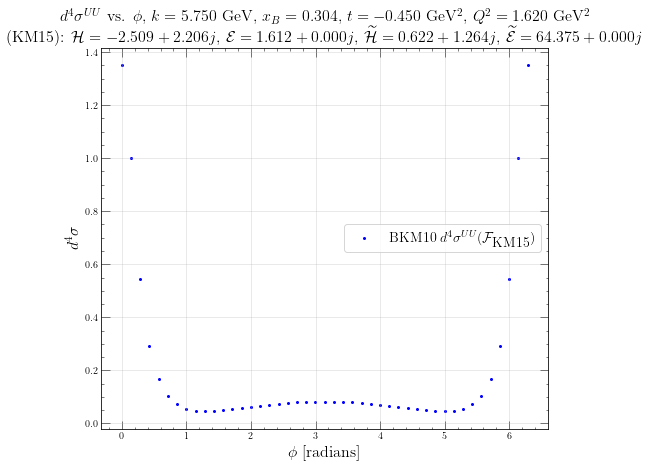

In [126]:
cross_section_fig, cross_section_axes = plt.subplots(1, figsize = (8, 7))

cross_section_axes.scatter(
    phi_array_in_radians, bkm10_unp_beam_unp_target_km15,
    s = 4., label = r"BKM10 $d^{4}\sigma^{UU}(\mathcal{F}_{\textrm{KM15}})$", color = "blue")

cross_section_axes.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
cross_section_axes.set_ylabel(r"$d^{4}\sigma$", fontsize = 16)
cross_section_axes.set_title(
    rf"$d^{{4}}\sigma^{{UU}}$ vs. $\phi$, {this_kinematic_set_title_string}"
    "\n"
    f"(KM15): {km15_cff_string}", fontsize = 16
)

cross_section_axes.legend(fontsize = 14)

cross_section_axes.grid(visible = True, alpha = 0.35)

#### (2.5.4): Plotting BSA Data:

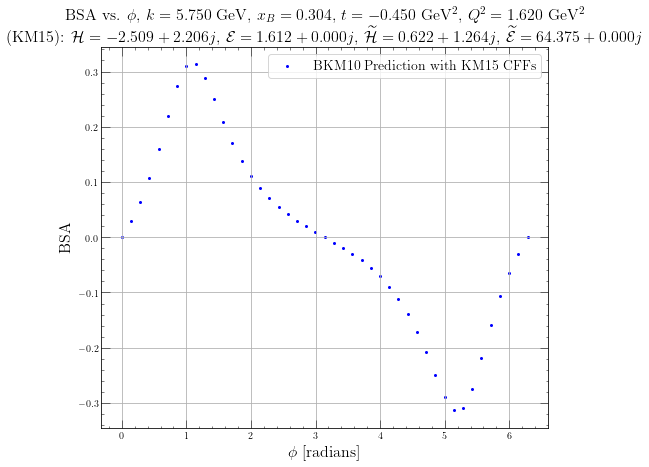

In [127]:
bsa_fig, bsa_axes = plt.subplots(1, figsize = (8, 7))

bsa_axes.scatter(
    phi_array_in_radians, bkm10_bsa_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

bsa_axes.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
bsa_axes.set_ylabel(r"BSA", fontsize = 16)
bsa_axes.set_title(
    rf"BSA vs. $\phi$, {this_kinematic_set_title_string}"
    "\n"
    f"(KM15): {km15_cff_string}", fontsize = 16)

bsa_axes.legend(fontsize = 14)
bsa_axes.grid(visible = True)

### (2.6): Piece Together Fixed Kinematic Settings, Varying Phi Data, and CFF Data into Pandas DataFrame:

In [128]:
test_dataframe = pd.DataFrame({
    "set": 1,
    # kinematics
    "k": FIXED_K, "q_squared": FIXED_Q_SQUARED, "x_b": FIXED_XB, "t": FIXED_T,
    "phi": phi_array_in_radians,
    # observables:
    "unp_beam_unp_target_xsec": bkm10_unp_beam_unp_target_km15, "unp_target_bsa": bkm10_bsa_km15,
    # KM15 CFFs:
    "Re[H]": real_h_values, "Im[H]": imag_h_values,
    "Re[E]": real_e_values, "Im[E]": imag_e_values,
    "Re[Ht]": real_ht_values, "Im[Ht]": imag_ht_values,
    "Re[Et]": real_et_values, "Im[Et]": imag_et_values
    }, 
    index = None)

#### (2.6.1): Checking Out the DataFrame with the Pseudodata:

In [129]:
test_dataframe.head()

,set,k,q_squared,x_b,t,phi,unp_beam_unp_target_xsec,unp_target_bsa,Re[H],Im[H],Re[E],Im[E],Re[Ht],Im[Ht],Re[Et],Im[Et]
0,1,5.75,1.62,0.304,-0.45,0.000000,1.349922,0.000000,-2.509044,2.205623,1.611898,0.0,0.622235,1.264367,64.37531,0.0
1,1,5.75,1.62,0.304,-0.45,0.142800,0.999593,0.030080,-2.509044,2.205623,1.611898,0.0,0.622235,1.264367,64.37531,0.0
2,1,5.75,1.62,0.304,-0.45,0.285599,0.543899,0.064418,-2.509044,2.205623,1.611898,0.0,0.622235,1.264367,64.37531,0.0
3,1,5.75,1.62,0.304,-0.45,0.428399,0.292153,0.106818,-2.509044,2.205623,1.611898,0.0,0.622235,1.264367,64.37531,0.0
4,1,5.75,1.62,0.304,-0.45,0.571199,0.167460,0.159256,-2.509044,2.205623,1.611898,0.0,0.622235,1.264367,64.37531,0.0


## (3): Data Preprocessing:

### (3.1): Define What Becomes the $x$ and $y$ Data:

**Important**: Define here what you want to train on!

In [130]:
x_data = test_dataframe[["t", "x_b", "q_squared", "phi"]]
y_data = test_dataframe[["unp_beam_unp_target_xsec", "unp_target_bsa"]]

TOTAL_DATA_SIZE = len(x_data)
print(f"[NOTE]: Total data size is: {TOTAL_DATA_SIZE}")

[NOTE]: Total data size is: 45


#### (3.1.1): Let's Check Out the $x$ DF:

In [131]:
x_data.head()

,t,x_b,q_squared,phi
0,-0.45,0.304,1.62,0.000000
1,-0.45,0.304,1.62,0.142800
2,-0.45,0.304,1.62,0.285599
3,-0.45,0.304,1.62,0.428399
4,-0.45,0.304,1.62,0.571199


#### (3.1.2): Let's Check Out the $y$ DF:

In [132]:
y_data.head()

,unp_beam_unp_target_xsec,unp_target_bsa
0,1.349922,0.000000
1,0.999593,0.030080
2,0.543899,0.064418
3,0.292153,0.106818
4,0.167460,0.159256


### (3.2): Train-Test Split Here:

#### (3.2.1): Define the Partition Percentages Here (Train/Validate/Test):

In [133]:
BATCH_SIZE = 20

# https://stackoverflow.com/a/13623707 -> for the typical train/val/test data split
# (we are *not* using the same numbers as recommended here)

_DNN_TESTING_TEMPORARY_SPLIT_PERCENTAGE = 0.1 # 90% temporary, 10% testing
_DNN_TRAINING_VALIDATION_SPLIT_PERCENTAGE = 0.1 # of the above 90% temporary, 90% training, 10% validation

number_of_dnn_testing_points = np.ceil(TOTAL_DATA_SIZE * _DNN_TESTING_TEMPORARY_SPLIT_PERCENTAGE)
number_of_dnn_temporary_points = TOTAL_DATA_SIZE - number_of_dnn_testing_points
number_of_dnn_validation_points = np.ceil(number_of_dnn_temporary_points * _DNN_TRAINING_VALIDATION_SPLIT_PERCENTAGE)
number_of_dnn_training_points = number_of_dnn_temporary_points - number_of_dnn_validation_points

print(f"[NOTE]: Testing/Temporary Split is {_DNN_TESTING_TEMPORARY_SPLIT_PERCENTAGE * 100}%, giving {number_of_dnn_testing_points} testing points")
print(f"[NOTE]: Training/Validation Split is {_DNN_TRAINING_VALIDATION_SPLIT_PERCENTAGE * 100}%, giving {number_of_dnn_validation_points} validation points")
print(f"[NOTE]: Remaining training data points are: {number_of_dnn_training_points}")

[NOTE]: Testing/Temporary Split is 10.0%, giving 5.0 testing points
[NOTE]: Training/Validation Split is 10.0%, giving 4.0 validation points
[NOTE]: Remaining training data points are: 36.0


#### (3.2.2): First Split: Split Entire Data into Testing and *Temporary*:

In [134]:
x_remaining, x_testing, y_remaining, y_testing = train_test_split(
    x_data, y_data,
    test_size = _DNN_TESTING_TEMPORARY_SPLIT_PERCENTAGE, shuffle = True)

#### (3.2.3): Second Split: Split *Temporary* Data into Training and Validation:

In [135]:
x_training, x_validation, y_training, y_validation = train_test_split(
    x_remaining, y_remaining,
    test_size = _DNN_TRAINING_VALIDATION_SPLIT_PERCENTAGE, shuffle = True)

print(f"[NOTE]: x-training size is: {len(x_training)}")
print(f"[NOTE]: x-validation size is: {len(x_validation)}")
print(f"[NOTE]: x-testing size is: {len(x_testing)}")

[NOTE]: x-training size is: 36
[NOTE]: x-validation size is: 4
[NOTE]: x-testing size is: 5


#### (3.2.4): Augment Original Datafile with Train/Test/Val Keywords:

In [136]:
# find their flags
train_flags = pd.DataFrame({'flag': 'train'}, index = x_training.index)
validation_flags = pd.DataFrame({'flag': 'validation'}, index = x_validation.index)
test_flags = pd.DataFrame({'flag': 'test'}, index = x_testing.index)

all_flags = pd.concat([train_flags, validation_flags, test_flags])

test_dataframe = test_dataframe.merge(
    all_flags, left_index = True, right_index = True, how = 'left')

test_dataframe.to_csv(
    path_or_buf = f"./local/version_{MAJOR_MINOR_NUMBER}/data/main_pseudodata_file_v{MAJOR_MINOR_NUMBER}.csv"
)

### (3.3): What does the pre-processed data look like?

#### (3.3.1): Training $x$ Features:

In [137]:
print(f"Size of x training: {len(x_training)}")
print(f"Does it match with what's expected? {len(x_training) == number_of_dnn_training_points}")

x_training.head()

Size of x training: 36
Does it match with what's expected? True


,t,x_b,q_squared,phi
38,-0.45,0.304,1.62,5.426387
30,-0.45,0.304,1.62,4.283990
18,-0.45,0.304,1.62,2.570394
28,-0.45,0.304,1.62,3.998391
16,-0.45,0.304,1.62,2.284795


#### (3.3.2): Training $y$ Labels:

In [138]:
print(f"Size of y training: {len(y_training)}")
print(f"Does it match with what's expected? {len(y_training) == number_of_dnn_training_points}")

y_training.head()

Size of y training: 36
Does it match with what's expected? True


,unp_beam_unp_target_xsec,unp_target_bsa
38,0.072006,-0.274633
30,0.061944,-0.111381
18,0.076925,0.041888
28,0.070229,-0.070757
16,0.070229,0.070757


#### (3.3.3): Checking out the Validation $x$ Features:

In [139]:
print(f"Size of x validation: {len(x_validation)}")
print(f"Does it match with what's expected? {len(x_validation) == number_of_dnn_validation_points}")

x_validation.head()

Size of x validation: 4
Does it match with what's expected? True


,t,x_b,q_squared,phi
27,-0.45,0.304,1.62,3.855591
24,-0.45,0.304,1.62,3.427192
8,-0.45,0.304,1.62,1.142397
44,-0.45,0.304,1.62,6.283185


#### (3.3.4): Checking out the Validation $y$ Features:

In [140]:
print(f"Size of y validation: {len(y_validation)}")
print(f"Does it match with what's expected? {len(y_validation) == number_of_dnn_validation_points}")

y_validation.head()

Size of y validation: 4
Does it match with what's expected? True


,unp_beam_unp_target_xsec,unp_target_bsa
27,0.073835,-0.055230
24,0.081237,-0.019515
8,0.048399,0.313089
44,1.349922,0.000000


#### (3.3.5): Checking out the Testing $x$ Features:

In [141]:
print(f"Size of x testing: {len(x_testing)}")
print(f"Does it match with what's expected? {len(x_testing) == number_of_dnn_testing_points}")

x_testing.head()

Size of x testing: 5
Does it match with what's expected? True


,t,x_b,q_squared,phi
11,-0.45,0.304,1.62,1.570796
20,-0.45,0.304,1.62,2.855993
42,-0.45,0.304,1.62,5.997586
32,-0.45,0.304,1.62,4.569589
1,-0.45,0.304,1.62,0.142800


#### (3.3.6): Checking out the Testing $y$ Features:

In [142]:
print(f"Size of y testing: {len(y_testing)}")
print(f"Does it match with what's expected? {len(y_testing) == number_of_dnn_testing_points}")

y_testing.head()

Size of y testing: 5
Does it match with what's expected? True


,unp_beam_unp_target_xsec,unp_target_bsa
11,0.049742,0.208615
20,0.081237,0.019515
42,0.543899,-0.064418
32,0.053411,-0.170670
1,0.999593,0.030080


### (3.4): Visualizing the Training/Validation/Testing Datapoints:

#### (3.4.1): Extracting the ($\phi$, $d^{4}\sigma$) Data Pairs in Train/Val/Test

In [143]:
# a numpy array of all the corresponding phi-points
# if you do NOT UNDERSTAND why the code below selects the phi-values that are used in training, please run each piece interactively
x_training_phi_points = np.array(x_training["phi"])
x_validation_phi_points = np.array(x_validation["phi"])
x_testing_phi_points = np.array(x_testing["phi"])

xsecs = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = FIXED_K, squared_Q_momentum_transfer = FIXED_Q_SQUARED,
            x_Bjorken = FIXED_XB, squared_hadronic_momentum_transfer_t = FIXED_T),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = CFF_H_KM15, compton_form_factor_h_tilde = CFF_H_TILDE_KM15,
            compton_form_factor_e = CFF_E_KM15, compton_form_factor_e_tilde = CFF_E_TILDE_KM15),
        "using_ww": True,
    },
    verbose = False, debugging = False)

x_training_bkm10_xsec = xsecs.compute_cross_section(
    x_training_phi_points, lepton_helicity = 0.0, target_polarization = 0.0).real

x_validation_bkm10_xsec = xsecs.compute_cross_section(
    x_validation_phi_points, lepton_helicity = 0.0, target_polarization = 0.0).real

x_testing_bkm10_xsec = xsecs.compute_cross_section(
    x_testing_phi_points, lepton_helicity = 0.0, target_polarization = 0.0).real

x_training_bkm10_bsa = xsecs.compute_bsa(
    x_training_phi_points, target_polarization = 0.0).real

x_validation_bkm10_bsa = xsecs.compute_bsa(
    x_validation_phi_points, target_polarization = 0.0).real

x_testing_bkm10_bsa = xsecs.compute_bsa(
    x_testing_phi_points, target_polarization = 0.0).real

#### (3.4.2): Making the Cross Section Plot:

In [144]:
data_vis_figure, data_vis_axis = plt.subplots(1, 1, figsize = (9, 9))

data_vis_axis.scatter(x_training_phi_points, x_training_bkm10_xsec, color = 'green', s = 4., label = rf"(KM15) Training Points ($N = {len(x_training_phi_points)}$)")
data_vis_axis.scatter(x_validation_phi_points, x_validation_bkm10_xsec, color = 'orange', s = 4., label = rf"(KM15) Validation Points ($N = {len(x_validation_phi_points)}$)")
data_vis_axis.scatter(x_testing_phi_points, x_testing_bkm10_xsec, color = 'red', s = 4., label = rf"(KM15) Testing Points ($N = {len(x_testing_phi_points)}$)")

data_vis_axis.legend(fontsize = 14.)

data_vis_axis.set_xlabel(r"$\phi$ [radians]", fontsize = 16.)
data_vis_axis.set_ylabel(r"$d^{4}\sigma$", fontsize = 16.)
data_vis_axis.set_title(
    rf"$d^{{4}}\sigma^{{UU}}$ vs. $\phi$, {this_kinematic_set_title_string}"
    "\n"
    f"(KM15): {km15_cff_string}", fontsize = 16
)

data_vis_axis.grid(visible = True, alpha = 0.35)

cross_section_visual_plotname = f"./local/version_{MAJOR_MINOR_NUMBER}/plots/train_test_split_cross_section_v{MAJOR_MINOR_NUMBER}"

for extension in ['png', 'eps']:
    data_vis_figure.savefig(
        f"{cross_section_visual_plotname}.{extension}",
        facecolor = 'white')
                            
plt.close(data_vis_figure)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


#### (3.4.3): Making the BSA Plot:

In [145]:
bsa_train_test_split_figure, bsa_train_test_split_axis = plt.subplots(1, 1, figsize = (9, 9))

bsa_train_test_split_axis.scatter(x_training_phi_points, x_training_bkm10_bsa, color = 'green', s = 4., label = rf"(KM15) Training Points $N = {len(x_training_phi_points)}$")
bsa_train_test_split_axis.scatter(x_validation_phi_points, x_validation_bkm10_bsa, color = 'orange', s = 4., label = rf"(KM15) Validation Points $N = {len(x_validation_phi_points)}$")
bsa_train_test_split_axis.scatter(x_testing_phi_points, x_testing_bkm10_bsa, color = 'red', s = 4., label = rf"(KM15) Testing Points $N = {len(x_testing_phi_points)}$")

bsa_train_test_split_axis.legend(fontsize = 14.)

bsa_train_test_split_axis.set_xlabel(r"$\phi$ [radians]", fontsize = 16.)
bsa_train_test_split_axis.set_ylabel(r"BSA", fontsize = 16.)
bsa_train_test_split_axis.set_title(
    rf"BSA vs. $\phi$, {this_kinematic_set_title_string}"
    "\n"
    f"(KM15): {km15_cff_string}", fontsize = 16)

bsa_visual_plotname = f"./local/version_{MAJOR_MINOR_NUMBER}/plots/train_test_split_bsa_v{MAJOR_MINOR_NUMBER}"

bsa_train_test_split_axis.grid(visible = True, alpha = 0.35)

for extension in ['png', 'eps']:
    bsa_train_test_split_figure.savefig(
        f"{bsa_visual_plotname}.{extension}",
        facecolor = 'white')

plt.close(bsa_train_test_split_figure)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


## (4): DNN Model Definitions:

We need to go through all of this section in order to get TensorFlow working with the BKM10 custom computation for the cross-section and BSA.

### (4.1): Static Quantities Used in Loss Computation:

**Important**: `Q_SQUARED` ($Q^{2}$) and `_LAB_K_BEAM` ($k$) are treated as fixed the ENTIRE TIME during training.

#### (4.1.1): Statics in Loss Computation:

In [146]:
_CONVERSION_GEV6_GEV4NB = .389379 * 1000000.
_MASS_OF_PROTON_IN_GEV = 0.93827208816
_QED_FINE_STRUCTURE = 1./137.035999177
_ELECTRIC_FORM_FACTOR_CONSTANT = 0.710649
_PROTON_MAGNETIC_MOMENT = 2.79284734463

### (4.1.2): Important Statics (Kinematics)

- `_LAB_K_BEAM` are **here**!!
- Only fix `_Q_SQUARED` if you want to neglect QCD evolution stuff!

In [147]:
_LAB_K_BEAM = test_dataframe["k"].iloc[0]

#### (4.1.2.1): Check Out the Static Quantities in the Kinematics:

Why did we use this `.iloc[0]`? Because we knew that the dataset doesn't change across a single kinematic bin; effectively, the dataset depicts the CFFs as functions of $\phi$ only. We could have chosen any one of the indices of the DF as an index, and it would have pulled out the same value for `_LAB_K_BEAM` and `_Q_SQUARED`. Proof is below:

In [148]:
print(f"Is it invariant under index? {test_dataframe['q_squared'].iloc[0] == test_dataframe['q_squared'].iloc[5]}")
print(f"Is it invariant under index? {test_dataframe['k'].iloc[0] == test_dataframe['k'].iloc[10]}")

Is it invariant under index? True
Is it invariant under index? True


In [149]:
print(f"Fixed k is: {_LAB_K_BEAM}")

Fixed k is: 5.75


### (4.2): Relevant Functions in Loss Computation:

#### (4.2.1): Kinematic Stuff:

In [150]:
def compute_fe(t):
    return 1./ (1. - (t / _ELECTRIC_FORM_FACTOR_CONSTANT))**2

def compute_fg(fe):
    return _PROTON_MAGNETIC_MOMENT * fe

def compute_f2(t, fe, fg):
    tau = -1. * t/ (4. * _MASS_OF_PROTON_IN_GEV**2)
    numerator = fg - fe
    denominator = 1. + tau
    return numerator / denominator

def compute_f1(fg, f2):
    return fg - f2

def compute_epsilon(xb, q_squared):
    return 2. * xb * _MASS_OF_PROTON_IN_GEV / tf.sqrt(q_squared)

def compute_y(k_beam, q_squared, ep):
    return tf.sqrt(q_squared) / (ep * k_beam)

def compute_skewness(xb, t, q_squared):
    return xb * (1. + (t / (2. * q_squared))) / (2. - xb + (xb * t / q_squared))

def compute_t_min(xb, q_squared, ep):
    return -1. * q_squared * ((2. * (1. - xb) * (1. - tf.sqrt(1. + ep**2))) + ep**2) / ((4. * xb * (1. - xb)) + ep**2)

def compute_t_prime(t, tmin):
    return (t-tmin)

def compute_k_tilde(xb, q_squared, t, tmin, ep):
    return tf.sqrt(tmin - t) * tf.sqrt(((1. - xb) * tf.sqrt((1. + ep**2))) + (((tmin - t) * (ep**2 + (4. * (1. - xb) * xb))) / (4. * q_squared)))

def compute_k(q_squared, y_lep, ep, k_tilde):
    return tf.sqrt(((1. - y_lep + (ep**2 * y_lep**2 / 4.)) / q_squared)) * k_tilde

def compute_k_dot_delta(q_squared, xb, t, phi_azi, ep, y_lep, k):
    return (-1.*q_squared / (2.*y_lep*(1.+ep**2))) * (1. + ((2.*k*tf.cos(tf.constant(np.pi) - phi_azi)) - ((t / q_squared)*(1.-(xb * (2. - y_lep)) + (y_lep * ep**2 / 2.))) + (y_lep * ep**2 / 2.)))

def prop_1(q_squared, kdd):
    return (1. + (2. * (kdd / q_squared)))

def prop_2(q_squared, t, kdd):
    return ((-2. * (kdd / q_squared)) + (t / q_squared))

#### (4.2.2): BH Coefficients:

In [151]:
def bh_unp_c0(
    q_sq: float, xb: float, t: float, ep: float,
    y: float, k: float, f1: float, f2: float):
    first_line = 8. * k**2 * (((2. + 3. * ep**2) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2))) / (t / q_sq)) + (2. * xb**2 * (f1 + f2)**2))
    second_line_first_part = (2. + ep**2) * ((4. * xb**2 * _MASS_OF_PROTON_IN_GEV**2 / t) * (1. + (t / q_sq))**2 + 4. * (1 - xb) * (1. + (xb * (t / q_sq)))) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2)))
    second_line_second_part = 4. * xb**2 * (xb + (1. - xb + (ep**2 / 2.)) * (1 - (t / q_sq))**2 - xb * (1. - 2. * xb) * (t / q_sq)**2) * (f1 + f2)**2
    second_line = (2. - y)**2 * (second_line_first_part + second_line_second_part)
    third_line = 8. * (1. + ep**2) * (1. - y - (ep**2 * y**2 / 4.)) * (2. * ep**2 * (1 - (t / (4. * _MASS_OF_PROTON_IN_GEV**2))) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2))) - xb**2 * (1 - (t / q_sq))**2 * (f1 + f2)**2)
    c0_unpolarized_bh = first_line + second_line + third_line
    return c0_unpolarized_bh

def bh_unp_c1(
    q_sq: float, xb: float, t: float, ep: float,
    y: float, k: float, f1: float, f2: float) -> float:
    addition_of_form_factors_squared = (f1 + f2)**2
    weighted_combination_of_form_factors = f1**2 - ((t / (4. * _MASS_OF_PROTON_IN_GEV**2)) * f2**2)
    first_line_first_part = ((4. * xb**2 * _MASS_OF_PROTON_IN_GEV**2 / t) - 2. * xb - ep**2) * weighted_combination_of_form_factors
    first_line_second_part = 2. * xb**2 * (1. - (1. - 2. * xb) * (t / q_sq)) * addition_of_form_factors_squared
    c1_unpolarized_bh = 8. * k * (2. - y) * (first_line_first_part + first_line_second_part)
    return c1_unpolarized_bh

def bh_unp_c2( 
    xb: float, t: float, k: float, f1: float, f2: float) -> float:
    addition_of_form_factors_squared = (f1 + f2)**2
    weighted_combination_of_form_factors = f1**2 - ((t/ (4. * _MASS_OF_PROTON_IN_GEV**2)) * f2**2)
    first_part_of_contribution = (4. * _MASS_OF_PROTON_IN_GEV**2 / t) * weighted_combination_of_form_factors
    c2_unpolarized_bh = 8. * xb**2 * k**2 * (first_part_of_contribution + 2. * addition_of_form_factors_squared)
    return c2_unpolarized_bh

def bh_lp_c0(
    lep_helicity: float,target_polar: float,
    q_sq: float, xb: float, t: float,ep: float,y: float, f1: float, f2: float) -> float:
    sum_of_form_factors = (f1 + f2)
    t_over_four_mp_squared = t / (4. * _MASS_OF_PROTON_IN_GEV**2)
    weighted_sum_of_form_factors = f1 + t_over_four_mp_squared * f2
    one_minus_xb = 1. - xb
    t_over_Q_squared = t / q_sq
    one_minus_t_over_Q_squared = 1. - t_over_Q_squared
    first_term_first_bracket = 0.5 * xb * (one_minus_t_over_Q_squared) - t_over_four_mp_squared
    first_term_second_bracket = 2. - xb - (2. * (one_minus_xb)**2 * t_over_Q_squared) + (ep**2 * one_minus_t_over_Q_squared) - (xb * (1. - 2. * xb) * t_over_Q_squared**2)
    first_term = 0.5 * sum_of_form_factors * first_term_first_bracket * first_term_second_bracket
    second_term_first_bracket = xb**2 * (1. + t_over_Q_squared)**2 / (4. * t_over_four_mp_squared) + ((1. - xb) * (1. + xb * t_over_Q_squared))
    second_term = (1. - (1. - xb) * t_over_Q_squared) * weighted_sum_of_form_factors * second_term_first_bracket
    prefactor = 8. * float(lep_helicity) * float(target_polar) * xb * (2. - y) * y * tf.sqrt(1. + ep**2) * sum_of_form_factors / (1. - t_over_four_mp_squared)
    c0LP_BH = prefactor * (first_term + second_term)
    return c0LP_BH

def bh_unp_c0(
    q_sq: float, xb: float, t: float, ep: float,
    y: float, k: float, f1: float, f2: float):
    first_line = 8. * k**2 * (((2. + 3. * ep**2) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2))) / (t / q_sq)) + (2. * xb**2 * (f1 + f2)**2))
    second_line_first_part = (2. + ep**2) * ((4. * xb**2 * _MASS_OF_PROTON_IN_GEV**2 / t) * (1. + (t / q_sq))**2 + 4. * (1 - xb) * (1. + (xb * (t / q_sq)))) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2)))
    second_line_second_part = 4. * xb**2 * (xb + (1. - xb + (ep**2 / 2.)) * (1 - (t / q_sq))**2 - xb * (1. - 2. * xb) * (t / q_sq)**2) * (f1 + f2)**2
    second_line = (2. - y)**2 * (second_line_first_part + second_line_second_part)
    third_line = 8. * (1. + ep**2) * (1. - y - (ep**2 * y**2 / 4.)) * (2. * ep**2 * (1 - (t / (4. * _MASS_OF_PROTON_IN_GEV**2))) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2))) - xb**2 * (1 - (t / q_sq))**2 * (f1 + f2)**2)
    c0_unpolarized_bh = first_line + second_line + third_line
    return c0_unpolarized_bh

def bh_unp_c1(
    q_sq: float, xb: float, t: float, ep: float,
    y: float, k: float, f1: float, f2: float) -> float:
    addition_of_form_factors_squared = (f1 + f2)**2
    weighted_combination_of_form_factors = f1**2 - ((t / (4. * _MASS_OF_PROTON_IN_GEV**2)) * f2**2)
    first_line_first_part = ((4. * xb**2 * _MASS_OF_PROTON_IN_GEV**2 / t) - 2. * xb - ep**2) * weighted_combination_of_form_factors
    first_line_second_part = 2. * xb**2 * (1. - (1. - 2. * xb) * (t / q_sq)) * addition_of_form_factors_squared
    c1_unpolarized_bh = 8. * k * (2. - y) * (first_line_first_part + first_line_second_part)
    return c1_unpolarized_bh

def bh_unp_c2( 
    xb: float, t: float, k: float, f1: float, f2: float) -> float:
    addition_of_form_factors_squared = (f1 + f2)**2
    weighted_combination_of_form_factors = f1**2 - ((t/ (4. * _MASS_OF_PROTON_IN_GEV**2)) * f2**2)
    first_part_of_contribution = (4. * _MASS_OF_PROTON_IN_GEV**2 / t) * weighted_combination_of_form_factors
    c2_unpolarized_bh = 8. * xb**2 * k**2 * (first_part_of_contribution + 2. * addition_of_form_factors_squared)
    return c2_unpolarized_bh

def bh_lp_c0(
    lep_helicity: float,target_polar: float,
    q_sq: float, xb: float, t: float,ep: float,y: float, f1: float, f2: float) -> float:
    sum_of_form_factors = (f1 + f2)
    t_over_four_mp_squared = t / (4. * _MASS_OF_PROTON_IN_GEV**2)
    weighted_sum_of_form_factors = f1 + t_over_four_mp_squared * f2
    one_minus_xb = 1. - xb
    t_over_Q_squared = t / q_sq
    one_minus_t_over_Q_squared = 1. - t_over_Q_squared
    first_term_first_bracket = 0.5 * xb * (one_minus_t_over_Q_squared) - t_over_four_mp_squared
    first_term_second_bracket = 2. - xb - (2. * (one_minus_xb)**2 * t_over_Q_squared) + (ep**2 * one_minus_t_over_Q_squared) - (xb * (1. - 2. * xb) * t_over_Q_squared**2)
    first_term = 0.5 * sum_of_form_factors * first_term_first_bracket * first_term_second_bracket
    second_term_first_bracket = xb**2 * (1. + t_over_Q_squared)**2 / (4. * t_over_four_mp_squared) + ((1. - xb) * (1. + xb * t_over_Q_squared))
    second_term = (1. - (1. - xb) * t_over_Q_squared) * weighted_sum_of_form_factors * second_term_first_bracket
    prefactor = 8. * float(lep_helicity) * float(target_polar) * xb * (2. - y) * y * tf.sqrt(1. + ep**2) * sum_of_form_factors / (1. - t_over_four_mp_squared)
    c0LP_BH = prefactor * (first_term + second_term)
    return c0LP_BH

def bh_lp_c1(
    lep_helicity: float,target_polar: float,
    q_sq: float, xb: float, t: float,ep: float,y: float,shorthand_k: float,f1: float, f2: float) -> float:
    sum_of_form_factors = (f1 + f2)
    t_over_four_mp_squared = t / (4. * _MASS_OF_PROTON_IN_GEV**2)
    weighted_sum_of_form_factors = f1 + t_over_four_mp_squared * f2
    t_over_Q_squared = t / q_sq
    first_term = ((2. * t_over_four_mp_squared) - (xb * (1. - t_over_Q_squared))) * ((1. - xb + (xb * t_over_Q_squared))) * sum_of_form_factors
    second_term_bracket_term = 1. + xb - ((3. - 2. * xb) * (1. + xb * t_over_Q_squared)) - (xb**2 * (1. + t_over_Q_squared**2) / t_over_four_mp_squared)
    second_term = weighted_sum_of_form_factors * second_term_bracket_term
    prefactor = -8. * lep_helicity * target_polar * xb * y * shorthand_k * tf.sqrt(1. + ep**2) * sum_of_form_factors / (1. - t_over_four_mp_squared)
    c1LP_BH = prefactor * (first_term + second_term)
    return c1LP_BH

#### (4.2.3): BH Amplitude Squared:

In [152]:
def bh_squared(lep_helicity, target_polar, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2):

    bh_c0 = bh_unp_c0(q_sq, xb, t, ep, y, k, f1, f2)
    bh_c1 = bh_unp_c1(q_sq, xb, t, ep, y, k, f1, f2)
    bh_c2 = bh_unp_c2(xb, t, k, f1, f2)

    bh_c0_lp = bh_lp_c0(lep_helicity, target_polar, q_sq, xb, t, ep, y, f1, f2)
    bh_c1_lp = bh_lp_c1(lep_helicity, target_polar, q_sq, xb, t, ep, y, k, f1, f2)

    return ((
        (bh_c0 + bh_c0_lp) * tf.cos(0.* (tf.constant(np.pi) - phi)) +
        (bh_c1 + bh_c1_lp) * tf.cos(1.* (tf.constant(np.pi) - phi)) + 
        (bh_c2 + 0.0) * tf.cos(2.* (tf.constant(np.pi) - phi))) / (xb * xb * y * y * (1.+ep**2)**2 * t * p1 * p2))

#### (4.2.4): DVCS Coefficients:

In [153]:
def f_eff(xi: float, cff: complex, use_ww: bool = True):
    if use_ww:
        cff_effective = 2. * cff / (1. + xi)
    else:
        cff_effective = -2. * xi * cff / (1. + xi)
    return cff_effective

def curly_c_real(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):
    
    first_line = (4.*(1.-xb)*(cff_re_h*cff_re_h_star - cff_im_h*cff_im_h_star)) + (4.*(1.-xb + 0.25*((2.*q_sq + t)*ep**2)/(q_sq + xb*t))*(cff_re_ht * cff_re_ht_star - cff_im_ht * cff_im_ht_star))
    next_line = -xb**2*(q_sq+t)**2*(cff_re_h*cff_re_e_star - cff_im_e*cff_im_h_star + cff_re_e*cff_re_h_star - cff_im_h*cff_im_e_star)/(q_sq*(q_sq+xb*t)) - (xb**2*q_sq*(cff_re_ht*cff_re_et_star - cff_im_et *cff_im_ht_star + cff_re_et*cff_re_ht_star - cff_im_ht*cff_im_et_star)/(q_sq+xb*t))
    final_line = -1.*(xb**2*(q_sq+t)**2/(q_sq*(q_sq+xb*t)) + 0.25*((2.-xb)*q_sq+xb*t)**2*t/(q_sq*_MASS_OF_PROTON_IN_GEV**2*(q_sq+xb*t)))*(cff_re_e*cff_re_e_star - cff_im_e*cff_im_e_star) -0.25*xb**2*q_sq*t*(cff_re_et*cff_re_et_star - cff_im_et*cff_im_et_star)/((q_sq+xb*t)*_MASS_OF_PROTON_IN_GEV**2)

    return ((first_line + next_line + final_line)*q_sq*(q_sq+xb*t)/((2.-xb)*q_sq+xb*t)**2)

def curly_c_imag(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):
    
    first_line = (4.*(1.-xb)*(cff_im_h*cff_re_h_star + cff_re_h*cff_im_h_star)) + (4.*(1.-xb + 0.25*(2.*q_sq + t)*ep**2/(q_sq + xb*t))*(cff_im_ht * cff_re_ht_star + cff_re_ht * cff_im_ht_star))
    next_line = -xb**2*(q_sq+t)**2*(cff_im_h*cff_re_e_star + cff_re_e*cff_im_h_star + cff_im_e*cff_re_h_star + cff_re_h*cff_im_e_star)/(q_sq*(q_sq+xb*t)) - (xb**2*q_sq*(cff_im_ht*cff_re_et_star + cff_re_et*cff_im_ht_star + cff_im_et*cff_re_ht_star + cff_re_ht*cff_im_et_star)/(q_sq+xb*t))
    final_line = -1.*(xb**2*(q_sq+t)**2/(q_sq*(q_sq+xb*t)) + 0.25*((2.-xb)*q_sq+xb*t)**2*t/(q_sq*_MASS_OF_PROTON_IN_GEV**2*(q_sq+xb*t)))*(cff_im_e*cff_re_e_star + cff_re_e*cff_im_e_star) -0.25*xb**2*q_sq*t*(cff_im_et*cff_re_et_star + cff_re_et*cff_im_et_star)/((q_sq+xb*t)*_MASS_OF_PROTON_IN_GEV**2)

    return ((first_line + next_line + final_line)*q_sq*(q_sq+xb*t)/((2.-xb)*q_sq+xb*t)**2)

def curly_c_real_lp(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):

    first_line=(4.*(1.-xb+(((3.-2.*xb)*q_sq + t))*ep*ep/(4.*(q_sq+xb*t)))*(cff_re_h*cff_re_ht_star-cff_im_ht*cff_im_h_star+cff_re_ht*cff_re_h_star-cff_im_h*cff_im_ht_star))
    second_line=-xb*xb*(q_sq-xb*t*(1.-2.*xb))*(cff_re_h*cff_re_et_star-cff_im_et*cff_im_h_star+cff_re_et*cff_re_h_star-cff_im_h*cff_im_et_star+cff_re_ht*cff_re_e_star-cff_im_e*cff_im_ht_star+cff_re_e*cff_re_ht_star-cff_im_ht*cff_im_e_star)/(q_sq+xb*t)
    third_line=-xb*((4.*(1.-xb)*(q_sq+xb*t)*t+ep*ep*(q_sq+t)**2)*(cff_re_ht*cff_re_e_star-cff_im_e*cff_im_ht_star+cff_re_e*cff_re_ht_star-cff_im_ht*cff_im_e_star))/(2.*q_sq*(q_sq+xb*t))
    fourth_line=-xb*((q_sq*(2.-xb)+xb*t)/(q_sq+xb*t))*((xb*xb*(q_sq+t)**2)/(2*q_sq*(q_sq*(2.-xb)+xb*t)) + t/(4.*_MASS_OF_PROTON_IN_GEV**2))*(cff_re_e*cff_re_et_star-cff_im_e*cff_im_et_star+cff_re_et*cff_re_e_star-cff_im_et*cff_im_e_star)

    return ((first_line+second_line+third_line+fourth_line)*q_sq*(q_sq+xb*t)/(tf.sqrt(1.+ep*ep)*((2.-xb)*q_sq+xb*t)**2))

def curly_c_imag_lp(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):

    first_line=(4.*(1.-xb+(((3.-2.*xb)*q_sq + t))*ep*ep/(4.*(q_sq+xb*t)))*(cff_im_h*cff_re_ht_star+cff_re_ht*cff_im_h_star+cff_im_ht*cff_re_h_star+cff_re_h*cff_im_ht_star))
    second_line=-xb*xb*(q_sq-xb*t*(1.-2.*xb))*(cff_im_h*cff_re_et_star+cff_re_et*cff_im_h_star+cff_im_et*cff_re_h_star+cff_re_h*cff_im_et_star+cff_im_ht*cff_re_e_star+cff_re_e*cff_im_ht_star+cff_im_e*cff_re_ht_star+cff_re_ht*cff_im_e_star)/(q_sq+xb*t)
    third_line=-xb*((4.*(1.-xb)*(q_sq+xb*t)*t+ep*ep*(q_sq+t)**2)*(cff_im_h*cff_re_et_star+cff_re_et*cff_im_h_star+cff_im_et*cff_re_h_star+cff_re_h*cff_im_et_star)/(2.*q_sq*(q_sq+xb*t)))
    fourth_line=-xb*((q_sq*(2.-xb)+xb*t)/(q_sq+xb*t))*((xb*xb*(q_sq+t)**2)/(2*q_sq*(q_sq*(2.-xb)+xb*t)) + t/(4.*_MASS_OF_PROTON_IN_GEV**2))*(cff_im_e*cff_re_et_star+cff_re_e*cff_im_et_star+cff_im_et*cff_re_e_star+cff_re_et*cff_im_e_star)

    return ((first_line+second_line+third_line+fourth_line)*q_sq*(q_sq+xb*t)/(tf.sqrt(1.+ep*ep)*((2.-xb)*q_sq+xb*t)**2))

def dvcs_unp_c0(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    cff_re_h: float,cff_re_ht: float,cff_re_e: float,cff_re_et: float,
    cff_im_h: float,cff_im_ht: float,cff_im_e: float,cff_im_et: float,
    use_ww: bool = True) -> float:
    
    first_term_prefactor = 2. * ( 2. - 2. * y + y**2 + (ep**2 * y**2 / 2.)) / (1. + ep**2)
    second_term_prefactor = 16. * k**2 / ((2. - xb)**2 * (1. + ep**2))
    first_term_curlyc = curly_c_real(
        q_sq, xb, t, ep,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        cff_im_h, cff_im_ht, cff_im_e, cff_im_et,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    second_term_curlyc = curly_c_real(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, -1.*cff_im_h, use_ww), f_eff(xi, -1.*cff_im_ht, use_ww), f_eff(xi, -1.*cff_im_e, use_ww), f_eff(xi, -1.*cff_im_et, use_ww))
    c0_dvcs_unpolarized_coefficient = first_term_prefactor * first_term_curlyc + second_term_prefactor * second_term_curlyc
    return c0_dvcs_unpolarized_coefficient

def dvcs_unp_c1(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    use_ww: bool = True) -> float:

    prefactor = 8. * k * (2. - y) / ((2. - xb) * (1. + ep**2))
    curlyC_unp_DVCS = curly_c_real(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)

def dvcs_unp_s1(
    lep_helicity: float,q_sq: float,xb: float,t: float,ep: float,y: float,xi: float, k: float,
    cff_re_h: float,cff_re_ht: float,cff_re_e: float,cff_re_et: float,
    cff_im_h: float,cff_im_ht: float,cff_im_e: float,cff_im_et: float,
    use_ww: bool = True) -> float:
    prefactor = -8. * k * lep_helicity * y * tf.sqrt(1. + ep**2) / ((2. - xb) * (1. + ep**2))
    curlyC_unp_DVCS = curly_c_imag(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)

def dvcs_lp_c0(
    lep_helicity: float, target_polar: float,
    q_sq: float,xb: float,t: float,ep: float,y: float,xi: float,k: float,
    cff_re_h: float,cff_re_ht: float,cff_re_e: float,cff_re_et: float,cff_im_h: float,cff_im_ht: float,cff_im_e: float,cff_im_et: float,
    use_ww: bool = True) -> float:

    prefactor = 2.*lep_helicity*target_polar*y*(2.-y)/tf.sqrt(1.+ep*ep)
    first_term_curlyc = curly_c_real_lp(
        q_sq, xb, t, ep,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        cff_im_h, cff_im_ht, cff_im_e, cff_im_et,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * first_term_curlyc)

def dvcs_lp_c1(
    lep_helicity: float, target_polar: float,
    q_sq: float,xb: float,t: float,ep: float,y: float,xi: float,k: float,
    cff_re_h: float,cff_re_ht: float,cff_re_e: float,cff_re_et: float,cff_im_h: float,cff_im_ht: float,cff_im_e: float,cff_im_et: float,
    use_ww: bool = True) -> float:

    prefactor = 8.*target_polar*k*lep_helicity*y*tf.sqrt(1+ep*ep)/((2.-xb)*(1.+ep*ep))
    curlyC_unp_DVCS = curly_c_real_lp(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)

def dvcs_lp_s1(
    lep_helicity: float, target_polar: float,
    q_sq: float,xb: float,t: float,ep: float,y: float,xi: float,k: float,
    cff_re_h: float,cff_re_ht: float,cff_re_e: float,cff_re_et: float,cff_im_h: float,cff_im_ht: float,cff_im_e: float,cff_im_et: float,
    use_ww: bool = True) -> float:

    prefactor = -8.*target_polar*k*(2.-y)/((2.-xb)*(1.+ep*ep))
    curlyC_unp_DVCS = curly_c_imag_lp(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)

#### (4.3.5): DVCS Amplitude Squared Function

In [154]:
def dvcs_squared(
    lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, phi,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    dvcs_c0 = dvcs_unp_c0(q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_c1 = dvcs_unp_c1(q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_s1 = dvcs_unp_s1(lep_helicity, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    
    dvcs_c0_lp = dvcs_lp_c0(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_c1_lp = dvcs_lp_c1(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_s1_lp = dvcs_lp_s1(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    return (
        (
            (dvcs_c0 + dvcs_c0_lp) * tf.cos(0.* (tf.constant(np.pi) - phi)) +
            (dvcs_c1 + dvcs_c1_lp) * tf.cos(1.* (tf.constant(np.pi) - phi)) + 
            (dvcs_s1 + dvcs_s1_lp) * tf.sin(1.* (tf.constant(np.pi) - phi))) / (y * y * q_sq))


#### (4.3.6): Interference Coefficients:

In [155]:
def i_c_unp_pp_0(
    q_sq: float,xb: float,t: float,ep: float,y: float,k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    two_minus_xb = 2. - xb
    two_minus_y = 2. - y
    first_term_in_brackets = k_tilde**2 * two_minus_y**2 / (q_sq * root_one_plus_epsilon_squared)
    second_term_in_brackets_first_part = t_over_Q_squared * two_minus_xb * (1. - y - (ep**2 * y**2 / 4.))
    second_term_in_brackets_second_part_numerator = 2. * xb * t_over_Q_squared * (two_minus_xb + 0.5 * (root_one_plus_epsilon_squared - 1.) + 0.5 * ep**2 / xb) + ep**2
    second_term_in_brackets_second_part =  1. + second_term_in_brackets_second_part_numerator / (two_minus_xb * one_plus_root_epsilon_stuff)
    prefactor = -4. * two_minus_y * one_plus_root_epsilon_stuff / tf.pow(root_one_plus_epsilon_squared, 4)
    c_0_plus_plus_unp = prefactor * (first_term_in_brackets + second_term_in_brackets_first_part * second_term_in_brackets_second_part)
    return c_0_plus_plus_unp

def i_c_unp_v_pp_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_term_in_brackets = (2. - y)**2 * k_tilde**2 / (root_one_plus_epsilon_squared * q_sq)
    second_term_first_multiplicative_term = 1. - y - (ep**2 * y**2 / 4.)
    second_term_second_multiplicative_term = one_plus_root_epsilon_stuff / 2.
    second_term_third_multiplicative_term = 1. + t_over_Q_squared
    second_term_fourth_multiplicative_term = 1. + (root_one_plus_epsilon_squared - 1. + (2. * xb)) * t_over_Q_squared / one_plus_root_epsilon_stuff
    second_term_in_brackets = second_term_first_multiplicative_term * second_term_second_multiplicative_term * second_term_third_multiplicative_term * second_term_fourth_multiplicative_term
    coefficient_prefactor = 8. * (2. - y) * xb * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_0_plus_plus_V_unp = coefficient_prefactor * (first_term_in_brackets + second_term_in_brackets)
    return c_0_plus_plus_V_unp

def i_c_unp_a_pp_0(
    q_sq: float,xb: float,t: float,ep: float,y: float,k_tilde: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    two_minus_y = 2. - y
    ktilde_over_Q_squared = k_tilde**2 / q_sq
    curly_bracket_first_term = two_minus_y**2 * ktilde_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb) / (2. * root_one_plus_epsilon_squared)
    deepest_parentheses_term = (xb * (2. + one_plus_root_epsilon_stuff - 2. * xb) / one_plus_root_epsilon_stuff + (one_plus_root_epsilon_stuff - 2.)) * t_over_Q_squared
    square_bracket_term = one_plus_root_epsilon_stuff * (one_plus_root_epsilon_stuff - xb + deepest_parentheses_term) / 2. - (2. * ktilde_over_Q_squared)
    curly_bracket_second_term = (1. - y - ep**2 * y**2 / 4.) * square_bracket_term
    coefficient_prefactor = 8. * two_minus_y * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_0_plus_plus_A_unp = coefficient_prefactor * (curly_bracket_first_term + curly_bracket_second_term)
    return c_0_plus_plus_A_unp

def i_c_unp_0p_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k: float):
    bracket_quantity = ep**2 + t * (2. - 6.* xb - ep**2) / (3. * q_sq)
    prefactor = 12. * tf.sqrt(2.) * k * (2. - y) * tf.sqrt(1. - y - (ep**2 * y**2 / 4)) / tf.pow(1. + ep**2, 2.5)
    c_0_zero_plus_unp = prefactor * bracket_quantity
    return c_0_zero_plus_unp

def i_c_unp_v_0p_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k: float):
    t_over_Q_squared = t / q_sq
    main_part = xb * t_over_Q_squared * (1. - (1. - 2. * xb) * t_over_Q_squared)
    prefactor = 24. * tf.sqrt(2.) * k * (2. - y) * tf.sqrt(1. - y - (y**2 * ep**2 / 4.)) / (1. + ep**2)**2.5
    c_0_zero_plus_V_unp = prefactor * main_part
    return c_0_zero_plus_V_unp

def i_c_unp_a_0p_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k: float):
    t_over_Q_squared = t / q_sq
    fancy_xb_epsilon_term = 8. - 6. * xb + 5. * ep**2
    brackets_term = 1. - t_over_Q_squared * (2. - 12. * xb * (1. - xb) - ep**2) / fancy_xb_epsilon_term
    prefactor = 4. * tf.sqrt(2.) * k * (2. - y) * tf.sqrt(1. - y - (y**2 * ep**2 / 4.)) / tf.pow(1. + ep**2, 2.5)
    c_0_zero_plus_A_unp = prefactor * t_over_Q_squared * fancy_xb_epsilon_term * brackets_term
    return c_0_zero_plus_A_unp

def i_c_unp_pp_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_bracket_first_term = (1. + (1. - x_Bjorken) * (root_one_plus_epsilon_squared - 1.) / (2. * x_Bjorken) + epsilon**2 / (4. * x_Bjorken)) * x_Bjorken * t_over_Q_squared
    first_bracket_term = first_bracket_first_term - 3. * epsilon**2 / 4.
    second_bracket_term = 1. - (1. - 3. * x_Bjorken) * t_over_Q_squared + (1. - root_one_plus_epsilon_squared + 3. * epsilon**2) * x_Bjorken * t_over_Q_squared / (one_plus_root_epsilon_stuff - epsilon**2)
    fancy_y_coefficient = 2. - 2. * lepton_energy_fraction_y + lepton_energy_fraction_y**2 + epsilon**2 * lepton_energy_fraction_y**2 / 2.
    second_term = -4. * shorthand_k * fancy_y_coefficient * (one_plus_root_epsilon_stuff - epsilon**2) * second_bracket_term / root_one_plus_epsilon_squared**5
    first_term = -16. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * first_bracket_term / root_one_plus_epsilon_squared**5
    c_1_plus_plus_unp = first_term + second_term
    return c_1_plus_plus_unp

def i_c_unp_v_pp_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    first_bracket_term = (2. - lepton_energy_fraction_y)**2 * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)
    second_bracket_term_first_part = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    second_bracket_term_second_part = 0.5 * (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * t_prime / squared_Q_momentum_transfer
    coefficient_prefactor = 16. * shorthand_k * x_Bjorken * t_over_Q_squared / tf.pow(root_one_plus_epsilon_squared, 5)
    c_1_plus_plus_V_unp = coefficient_prefactor * (first_bracket_term + second_bracket_term_first_part * second_bracket_term_second_part)
    return c_1_plus_plus_V_unp

def i_c_unp_a_pp_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    one_minus_2xb = 1. - 2. * x_Bjorken
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    first_bracket_term_second_part = 1. - one_minus_2xb * t_over_Q_squared + (4. * x_Bjorken * one_minus_xb + epsilon**2) * t_prime_over_Q_squared / (4. * root_one_plus_epsilon_squared)
    second_bracket_term = 1. - 0.5 * x_Bjorken + 0.25 * (one_minus_2xb + root_one_plus_epsilon_squared) * (1. - t_over_Q_squared) + (4. * x_Bjorken * one_minus_xb + epsilon**2) * t_prime_over_Q_squared / (2. * root_one_plus_epsilon_squared)
    prefactor = -16. * shorthand_k * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_1_plus_plus_A_unp = prefactor * (fancy_y_stuff * first_bracket_term_second_part - (2. - lepton_energy_fraction_y)**2 * second_bracket_term)
    return c_1_plus_plus_A_unp

def i_c_unp_0p_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    first_bracket_term = (2. - lepton_energy_fraction_y)**2 * t_prime_over_Q_squared * (one_minus_xb + (one_minus_xb * x_Bjorken + (epsilon**2 / 4.)) * t_prime_over_Q_squared / root_one_plus_epsilon_squared)
    second_bracket_term = y_quantity * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared) * (epsilon**2 - 2. * (1. + (epsilon**2 / (2. * x_Bjorken))) * x_Bjorken * t_over_Q_squared) / root_one_plus_epsilon_squared
    prefactor = 8. * tf.sqrt(2. * y_quantity) / root_one_plus_epsilon_squared**4
    c_1_zero_plus_unp = prefactor * (first_bracket_term + second_bracket_term)
    return c_1_zero_plus_unp

def i_c_unp_v_0p_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    k_tilde: float):
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    major_part = (2 - lepton_energy_fraction_y)**2 * k_tilde**2 / squared_Q_momentum_transfer + (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)**2 * y_quantity
    prefactor = 16. * tf.sqrt(2. * y_quantity) * x_Bjorken * t_over_Q_squared / (1. + epsilon**2)**2.5
    c_1_zero_plus_V_unp = prefactor * major_part
    return c_1_zero_plus_V_unp

def i_c_unp_a_0p_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    one_minus_2xb = 1. - 2. * x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    second_term_first_part = (1. - one_minus_2xb * t_over_Q_squared) * y_quantity
    second_term_second_part = 4. - 2. * x_Bjorken + 3. * epsilon**2 + t_over_Q_squared * (4. * x_Bjorken * (1. - x_Bjorken) + epsilon**2)
    first_term = k_tilde**2 * one_minus_2xb * (2. - lepton_energy_fraction_y)**2 / squared_Q_momentum_transfer
    prefactor = 8. * tf.sqrt(2. * y_quantity) * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_1_zero_plus_unp_A = prefactor * (first_term + second_term_first_part * second_term_second_part)
    return c_1_zero_plus_unp_A

def i_c_unp_pp_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    first_bracket_term = 2. * epsilon**2 * k_tilde**2 / (root_one_plus_epsilon_squared * (1. + root_one_plus_epsilon_squared) * squared_Q_momentum_transfer)
    second_bracket_term = x_Bjorken * t_prime * t_over_Q_squared * (1. - x_Bjorken - 0.5 * (root_one_plus_epsilon_squared - 1.) + 0.5 * epsilon**2 / x_Bjorken) / squared_Q_momentum_transfer
    prefactor = 8. * (2. - lepton_energy_fraction_y) * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) / root_one_plus_epsilon_squared**4
    c_2_plus_plus_unp = prefactor * (first_bracket_term + second_bracket_term)
    return c_2_plus_plus_unp

def i_c_unp_v_pp_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    major_term = (4. * k_tilde**2 / (root_one_plus_epsilon_squared * squared_Q_momentum_transfer)) + 0.5 * (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * (1. + t_over_Q_squared) * t_prime_over_Q_squared
    prefactor = 8. * (2. - lepton_energy_fraction_y) * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_plus_plus_V_unp = prefactor * major_term
    return c_2_plus_plus_V_unp

def i_c_unp_a_pp_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    first_bracket_term = 4. * (1. - 2. * x_Bjorken) * k_tilde**2 / (root_one_plus_epsilon_squared * squared_Q_momentum_transfer)
    second_bracket_term = (3.  - root_one_plus_epsilon_squared - 2. * x_Bjorken + epsilon**2 / x_Bjorken ) * x_Bjorken * t_prime_over_Q_squared
    prefactor = 4. * (2. - lepton_energy_fraction_y) * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_plus_plus_A_unp = prefactor * (first_bracket_term - second_bracket_term)
    return c_2_plus_plus_A_unp

def i_c_unp_0p_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    epsilon_squared_over_2 = epsilon**2 / 2.
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    bracket_term = 1. + ((1. + epsilon_squared_over_2 / x_Bjorken) / (1. + epsilon_squared_over_2)) * x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    prefactor = -8. * tf.sqrt(2. * y_quantity) * shorthand_k * (2. - lepton_energy_fraction_y) / root_one_plus_epsilon_squared**5
    c_2_zero_plus_unp = prefactor * (1. + epsilon_squared_over_2) * bracket_term
    return c_2_zero_plus_unp

def i_c_unp_v_0p_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    y_quantity = tf.sqrt(1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.))
    prefactor = 8. * tf.sqrt(2.) * y_quantity * shorthand_k * (2. - lepton_energy_fraction_y) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_2_zero_plus_unp_V = prefactor * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)
    return c_2_zero_plus_unp_V

def i_c_unp_a_0p_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    bracket_term = one_minus_xb + 0.5 * t_prime_over_Q_squared * (4. * x_Bjorken * one_minus_xb + epsilon**2) / root_one_plus_epsilon_squared
    prefactor = 8. * tf.sqrt(2. * y_quantity) * shorthand_k * (2. - lepton_energy_fraction_y) * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_zero_plus_unp_A = prefactor * bracket_term
    return c_2_zero_plus_unp_A

def i_c_unp_pp_3(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    major_term = (1. - x_Bjorken) * t_over_Q_squared + 0.5 * (root_one_plus_epsilon_squared - 1.) * (1. + t_over_Q_squared)
    intermediate_term = (root_one_plus_epsilon_squared - 1.) / root_one_plus_epsilon_squared**5
    prefactor = -8. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    c_3_plus_plus_unp = prefactor * intermediate_term * major_term
    return c_3_plus_plus_unp

def i_c_unp_v_pp_3(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    major_term = root_one_plus_epsilon_squared - 1. + (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * t_over_Q_squared
    prefactor = -8. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_3_plus_plus_V_unp = prefactor * major_term
    return c_3_plus_plus_V_unp

def i_c_unp_a_pp_3(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    main_term = squared_hadronic_momentum_transfer_t * t_prime * (x_Bjorken * (1. - x_Bjorken) + epsilon**2 / 4.) / squared_Q_momentum_transfer**2
    prefactor = 16. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) / (1. + epsilon**2)**2.5
    c_3_plus_plus_A_unp = prefactor * main_term
    return c_3_plus_plus_A_unp

def i_s_unp_pp_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    bracket_term = 1. + ((1. - x_Bjorken + 0.5 * (root_one_plus_epsilon_squared - 1.)) / root_one_plus_epsilon_squared**2) * tPrime_over_Q_squared
    prefactor = 8. * lepton_helicity * shorthand_k * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) / root_one_plus_epsilon_squared**2
    s_1_plus_plus_unp = prefactor * bracket_term
    return s_1_plus_plus_unp

def i_s_unp_v_pp_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    bracket_term = root_one_plus_epsilon_squared - 1. + (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * t_over_Q_squared
    prefactor = -8. * lepton_helicity * shorthand_k * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    s_1_plus_plus_unp_V = prefactor * bracket_term
    return s_1_plus_plus_unp_V

def i_s_unp_a_pp_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_2xb = 1. - 2. * x_Bjorken
    bracket_term = 1. - one_minus_2xb * (one_minus_2xb + root_one_plus_epsilon_squared) * tPrime_over_Q_squared / (2. * root_one_plus_epsilon_squared)
    prefactor = 8. * lepton_helicity * shorthand_k * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * t_over_Q_squared / root_one_plus_epsilon_squared**2
    s_1_plus_plus_unp_A = prefactor * bracket_term
    return s_1_plus_plus_unp_A

def i_s_unp_0p_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    epsilon: float,
    lepton_energy_fraction_y: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = (1. + epsilon**2)**2
    y_quantity = tf.sqrt(1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.))
    s_1_zero_plus_unp = 8. * tf.sqrt(2.) * lepton_helicity * (2. - lepton_energy_fraction_y) * lepton_energy_fraction_y * y_quantity * k_tilde**2 / (root_one_plus_epsilon_squared * squared_Q_momentum_transfer)
    return s_1_zero_plus_unp

def i_s_unp_v_0p_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float):
    one_plus_epsilon_squared_squared = (1. + epsilon**2)**2
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    bracket_term = 4. * (1. - 2. * x_Bjorken) * t_over_Q_squared * (1. + x_Bjorken * t_over_Q_squared) + epsilon**2 * (1. + t_over_Q_squared)**2
    prefactor = 4. * tf.sqrt(2. * fancy_y_stuff) * lepton_helicity * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * x_Bjorken * t_over_Q_squared / one_plus_epsilon_squared_squared
    s_1_zero_plus_unp_V = prefactor * bracket_term
    return s_1_zero_plus_unp_V

def i_s_unp_a_0p_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    one_plus_epsilon_squared_squared = (1. + epsilon**2)**2
    fancy_y_stuff = tf.sqrt(1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    prefactor = -8. * tf.sqrt(2.) * lepton_helicity * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * (1. - 2. * x_Bjorken) / one_plus_epsilon_squared_squared
    s_1_zero_plus_unp_A = prefactor * fancy_y_stuff * squared_hadronic_momentum_transfer_t * shorthand_k**2 / squared_Q_momentum_transfer
    return s_1_zero_plus_unp_A

def i_s_unp_pp_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    first_bracket_term = (epsilon**2 - x_Bjorken * (root_one_plus_epsilon_squared - 1.)) / (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken)
    second_bracket_term = (2. * x_Bjorken + epsilon**2) * tPrime_over_Q_squared / (2. * root_one_plus_epsilon_squared)
    prefactor = -4. * lepton_helicity * fancy_y_stuff * lepton_energy_fraction_y * (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * tPrime_over_Q_squared / root_one_plus_epsilon_squared**3
    s_2_plus_plus_unp = prefactor * (first_bracket_term - second_bracket_term)
    return s_2_plus_plus_unp

def i_s_unp_v_pp_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    one_minus_2xb = 1. - 2. * x_Bjorken
    bracket_term = root_one_plus_epsilon_squared - 1. + (one_minus_2xb + root_one_plus_epsilon_squared) * t_over_Q_squared
    parentheses_term = 1. - one_minus_2xb * t_over_Q_squared
    prefactor = -4. * lepton_helicity * fancy_y_stuff * lepton_energy_fraction_y * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    s_2_plus_plus_unp_V = prefactor * parentheses_term * bracket_term
    return s_2_plus_plus_unp_V

def i_s_unp_a_pp_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    last_term = 1. + (4. * (1. - x_Bjorken) * x_Bjorken + epsilon**2) * t_over_Q_squared / (4. - 2. * x_Bjorken + 3. * epsilon**2)
    middle_term = 1. + root_one_plus_epsilon_squared - 2. * x_Bjorken
    prefactor = -8. * lepton_helicity * fancy_y_stuff * lepton_energy_fraction_y * t_over_Q_squared * tPrime_over_Q_squared / root_one_plus_epsilon_squared**4
    s_2_plus_plus_unp_A = prefactor * middle_term * last_term
    return s_2_plus_plus_unp_A

def i_s_unp_0p_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    epsilon_squared_over_2 = epsilon**2 / 2.
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    bracket_term = 1. + ((1. + epsilon_squared_over_2 / x_Bjorken) / (1. + epsilon_squared_over_2)) * x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    prefactor = 8. * lepton_helicity * tf.sqrt(2. * y_quantity) * shorthand_k * lepton_energy_fraction_y / root_one_plus_epsilon_squared**4
    s_2_zero_plus_unp = prefactor * (1. + epsilon_squared_over_2) * bracket_term
    return s_2_zero_plus_unp

def i_s_unp_v_0p_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    y_quantity = tf.sqrt(1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.))
    prefactor = -8. * tf.sqrt(2.) * lepton_helicity * y_quantity * shorthand_k * lepton_energy_fraction_y * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    s_2_zero_plus_unp_V = prefactor * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)
    return s_2_zero_plus_unp_V

def i_s_unp_a_0p_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    main_term = 4. * one_minus_xb + 2. * epsilon**2 + 4. * t_over_Q_squared * (4. * x_Bjorken * one_minus_xb + epsilon**2)
    prefactor = -2. * tf.sqrt(2. * y_quantity) * lepton_helicity * shorthand_k * lepton_energy_fraction_y * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_zero_plus_unp_A = prefactor * main_term
    return c_2_zero_plus_unp_A

def i_curly_c_unp(
    squared_Q_momentum_transfer: float,
    x_Bjorken: float,
    squared_hadronic_momentum_transfer_t: float,
    Dirac_form_factor_F1: float,
    Pauli_form_factor_F2: float,
    cff_h: float,
    cff_h_tilde: float,
    cff_e: float) -> float:
    weighted_cffs = (Dirac_form_factor_F1 * cff_h) - (squared_hadronic_momentum_transfer_t * Pauli_form_factor_F2 * cff_e / (4. * _MASS_OF_PROTON_IN_GEV**2))
    second_term = x_Bjorken * (Dirac_form_factor_F1 + Pauli_form_factor_F2) * cff_h_tilde / (2. - x_Bjorken + (x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer))
    curly_C_unpolarized_interference = weighted_cffs + second_term
    return curly_C_unpolarized_interference

def i_curly_c_v_unp(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float,
    squared_hadronic_momentum_transfer_t: float,
    Dirac_form_factor_F1: float,
    Pauli_form_factor_F2: float,
    cff_h: float,
    cff_e: float) -> float:
    cff_term = cff_h + cff_e
    second_term = x_Bjorken * (Dirac_form_factor_F1 + Pauli_form_factor_F2) / (2. - x_Bjorken + (x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer))
    curly_C_unpolarized_interference_V = cff_term * second_term
    return curly_C_unpolarized_interference_V

def i_curly_c_a_unp(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float,
    squared_hadronic_momentum_transfer_t: float,
    Dirac_form_factor_F1: float,
    Pauli_form_factor_F2: float,
    cff_ht: float) -> float:
    xb_modulation = x_Bjorken * (Dirac_form_factor_F1 + Pauli_form_factor_F2) / (2. - x_Bjorken + (x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer))
    curly_C_unpolarized_interference_A = cff_ht * xb_modulation
    return curly_C_unpolarized_interference_A

def i_c_lp_pp_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq 
    first_bracket_term = (2. - y)**2 * k_tilde**2 / q_sq
    second_bracket_term_first_part = 1. - y + (ep**2 * y**2 / 4.)
    second_bracket_term_second_part = xb * t_over_Q_squared - (ep**2 * (1. - t_over_Q_squared) / 2.)
    second_bracket_term_third_part = 1. + t_over_Q_squared * ((root_one_plus_epsilon_squared - 1. + 2. * xb) / (1. + root_one_plus_epsilon_squared))
    second_bracket_term = second_bracket_term_first_part * second_bracket_term_second_part * second_bracket_term_third_part
    prefactor = -4. * lep_helicity * target_polar * y * (1. + root_one_plus_epsilon_squared) / root_one_plus_epsilon_squared**5
    c_0_plus_plus_LP = prefactor * (first_bracket_term + second_bracket_term)
    return c_0_plus_plus_LP

def i_c_lp_v_pp_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_bracket_term = (2. - y)**2 * (one_plus_root_epsilon_stuff - 2. * xb) * k_tilde**2 / (q_sq * one_plus_root_epsilon_stuff)
    second_bracket_term_first_part = 1. - y - (ep**2 * y**2 / 4.)
    second_bracket_term_second_part = 2. - xb + 3. * ep**2 / 2
    second_bracket_term_third_part = 1. + (t_over_Q_squared * (4. * (1. - xb) * xb + ep**2) / (4. - 2. * xb + 3. * ep**2))
    second_bracket_term_fourth_part = 1. + (t_over_Q_squared * (one_plus_root_epsilon_stuff - 2. + 2. * xb) / one_plus_root_epsilon_stuff)
    second_bracket_term = second_bracket_term_first_part * second_bracket_term_second_part * second_bracket_term_third_part * second_bracket_term_fourth_part
    prefactor = 4. * lep_helicity * target_polar * y * one_plus_root_epsilon_stuff * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_0_plus_plus_V_LP = prefactor * (first_bracket_term + second_bracket_term)
    return c_0_plus_plus_V_LP

def i_c_lp_a_pp_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_bracket_term = 2. * (2. - y)**2 * k_tilde**2 / q_sq
    second_bracket_term_first_part = 1. - y - (ep**2 * y**2 / 4.)
    second_bracket_term_second_part = 1. - (1. - 2. * xb) * t_over_Q_squared
    second_bracket_term_third_part = 1. + (t_over_Q_squared * (root_one_plus_epsilon_squared - 1. + 2. * xb) / one_plus_root_epsilon_stuff)
    second_bracket_term = second_bracket_term_first_part * one_plus_root_epsilon_stuff * second_bracket_term_second_part * second_bracket_term_third_part
    prefactor = 4. * lep_helicity * target_polar * y * xb * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_0_plus_plus_A_LP = prefactor * (first_bracket_term + second_bracket_term)
    return c_0_plus_plus_A_LP

def i_c_lp_0p_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * tf.sqrt(2.) * lep_helicity * target_polar * shorthand_k * (1. - xb) * y / (1. + ep**2)**2
    c_0_zero_plus_LP = prefactor * root_combination_of_y_and_epsilon * t / q_sq
    return c_0_zero_plus_LP

def i_c_lp_v_0p_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    modulating_factor = (xb - (t * (1. - 2. * xb) / q_sq)) / (1. - xb)
    c_0_zero_plus_LP = i_c_lp_0p_0(
        lep_helicity,
        target_polar,
        q_sq, 
        xb, 
        t,
        ep,
        y, 
        shorthand_k)
    c_0_zero_plus_V_LP = c_0_zero_plus_LP * modulating_factor
    return c_0_zero_plus_V_LP

def i_c_lp_a_0p_0(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = -8. * tf.sqrt(2.) * lep_helicity * target_polar * shorthand_k * y / (1. + ep**2)**2
    t_over_Q_squared = t / q_sq
    c_0_zero_plus_A_LP = prefactor * root_combination_of_y_and_epsilon * xb * t_over_Q_squared * (1. + t_over_Q_squared)
    return c_0_zero_plus_A_LP

def i_c_lp_0p_1(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    ep: float,
    y: float, 
    k_tilde: float,
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = -8. * tf.sqrt(2.) * lep_helicity * target_polar * shorthand_k * (1. - y) * y / (1. + ep**2)**2
    c_1_zero_plus_LP = prefactor * root_combination_of_y_and_epsilon * k_tilde**2 / q_sq
    return c_1_zero_plus_LP

def i_c_lp_v_0p_1(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * tf.sqrt(2.) * lep_helicity * target_polar  * (2. - y) * y / (1. + ep**2)**2
    c_1_zero_plus_V_LP = prefactor * root_combination_of_y_and_epsilon * t * k_tilde**2 / q_sq**2
    return c_1_zero_plus_V_LP

def i_c_lp_pp_1(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    one_plus_root_epsilon_minus_epsilon_squared = one_plus_root_epsilon_stuff - ep**2
    major_factor = 1. - ((t / q_sq) * (1. - 2. * xb * (one_plus_root_epsilon_stuff + 1.) / one_plus_root_epsilon_minus_epsilon_squared))
    prefactor = -4. * lep_helicity * target_polar * y * shorthand_k * (2. - y) / root_one_plus_epsilon_squared**5
    c_1_plus_plus_LP = prefactor * one_plus_root_epsilon_minus_epsilon_squared * major_factor
    return c_1_plus_plus_LP

def i_c_lp_v_pp_1(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    t_prime: float,
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    one_minus_xb = 1. - xb
    root_epsilon_and_xb_quantity = root_one_plus_epsilon_squared + 2. * one_minus_xb
    bracket_factor_numerator = 1. + ((1. - ep**2) / root_one_plus_epsilon_squared) - (2. * xb * (1. + (4. * one_minus_xb / root_one_plus_epsilon_squared)))
    bracket_factor_denominator = 2. * root_epsilon_and_xb_quantity
    bracket_factor = 1. - (t_prime * bracket_factor_numerator / (q_sq * bracket_factor_denominator))
    prefactor = 8. * lep_helicity * target_polar * shorthand_k * y * (2. - y) / root_one_plus_epsilon_squared**4
    c_1_plus_plus_V_LP = prefactor * root_epsilon_and_xb_quantity * t * bracket_factor / q_sq
    return c_1_plus_plus_V_LP
    
def i_c_lp_a_pp_1(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    t_over_Q_squared = t / q_sq
    major_factor = xb * t_over_Q_squared * (1. - (1. - 2. * xb) * t_over_Q_squared)
    prefactor = 16. * lep_helicity * target_polar * shorthand_k * y * (2. - y) / tf.sqrt(1. + ep**2)**5
    c_1_plus_plus_A_LP = prefactor * major_factor
    return c_1_plus_plus_A_LP

def i_c_lp_pp_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_multiplicative_factor = (-1. * one_plus_root_epsilon_stuff + 2.) - t_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb)
    second_multiplicative_factor = xb * t_over_Q_squared - (ep**2 * (1. - t_over_Q_squared) / 2.)
    prefactor = -4. * lep_helicity * target_polar * y * (1. - y - (y**2 * ep**2 / 4.)) / root_one_plus_epsilon_squared**5
    c_2_plus_plus_LP = prefactor * first_multiplicative_factor * second_multiplicative_factor
    return c_2_plus_plus_LP

def i_c_lp_v_pp_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_multiplicative_factor = (one_plus_root_epsilon_stuff - 2.) + t_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb)
    second_multiplicative_factor = 1. + (t_over_Q_squared * (4. * (1. - xb) * xb + ep**2 ) / (4. - 2. * xb + 3. * ep**2))
    third_multiplicative_factor = t_over_Q_squared * (4. - 2. * xb + 3. * ep**2)
    prefactor = -2.*lep_helicity*target_polar*y*(1.-y-(y**2 * ep**2 / 4.)) / root_one_plus_epsilon_squared**5
    c_2_plus_plus_V_LP = prefactor * first_multiplicative_factor * second_multiplicative_factor * third_multiplicative_factor
    return c_2_plus_plus_V_LP

def i_c_lp_a_pp_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_multiplicative_factor = (1. - root_one_plus_epsilon_squared) - t_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb)
    second_multiplicative_factor = xb * t_over_Q_squared * (1. - t_over_Q_squared * (1. - 2. * xb))
    prefactor = 4. * lep_helicity * target_polar * y * (1. - y - (y**2 * ep**2 / 4.)) / root_one_plus_epsilon_squared**5
    c_2_plus_plus_A_LP = prefactor * first_multiplicative_factor * second_multiplicative_factor
    return c_2_plus_plus_A_LP

def i_c_lp_0p_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = -8. * tf.sqrt(2.) * lep_helicity * target_polar * shorthand_k * y / (1. + ep**2)**2
    c_2_zero_plus_LP = prefactor * root_combination_of_y_and_epsilon * (1. + (xb * t / q_sq))
    return c_2_zero_plus_LP

def i_c_lp_v_0p_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * tf.sqrt(2.) * lep_helicity * target_polar * shorthand_k * y / (1. + ep**2)**2
    c_2_zero_plus_V_LP = prefactor * root_combination_of_y_and_epsilon * (1. - xb ) * t / q_sq
    return c_2_zero_plus_V_LP

def i_c_lp_v_0p_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * tf.sqrt(2.) * lep_helicity * target_polar * shorthand_k * y / (1. + ep**2)**2
    c_2_zero_plus_V_LP = prefactor * root_combination_of_y_and_epsilon * (1. - xb ) * t / q_sq
    return c_2_zero_plus_V_LP

def i_c_lp_a_0p_2(
    lep_helicity: float,
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * tf.sqrt(2.) * lep_helicity * target_polar * shorthand_k * y / (1. + ep**2)**2
    t_over_Q_squared = t / q_sq
    c_2_zero_plus_A_LP = prefactor * root_combination_of_y_and_epsilon * xb * t_over_Q_squared * (1. + t / q_sq)
    return c_2_zero_plus_A_LP

def i_s_lp_pp_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    t_over_Q_squared = t / q_sq
    epsilon_y_over_2_squared = (ep * y / 2.) ** 2
    first_bracket_term = 2. * root_one_plus_epsilon_squared - 1. + (t_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb) / one_plus_root_epsilon_stuff)
    second_bracket_term = (3. * ep**2 / 2.) + (t_over_Q_squared * (1. - root_one_plus_epsilon_squared - ep**2 / 2. - xb * (3.  - root_one_plus_epsilon_squared)))
    almost_prefactor = 4. * target_polar * shorthand_k / root_one_plus_epsilon_squared**6
    prefactor_one = almost_prefactor * (2. - 2. * y + y**2 + 2. * epsilon_y_over_2_squared) * one_plus_root_epsilon_stuff
    prefactor_two = 2. * almost_prefactor * (1. - y - epsilon_y_over_2_squared)
    s_1_plus_plus_LP = prefactor_one * first_bracket_term + prefactor_two * second_bracket_term
    return s_1_plus_plus_LP

def i_s_lp_v_pp_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    t_prime: float,
    shorthand_k: float) -> float:
    ep_squared = ep**2
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep_squared)
    t_over_Q_squared = t / q_sq
    t_prime_over_Q_squared = t_prime / q_sq
    epsilon_y_over_2_squared = ep_squared * y**2 / 4.
    first_bracket_term = 1. - (t_prime_over_Q_squared * ((1. - 2. * xb) * (1. - 2. * xb + root_one_plus_epsilon_squared)) / (2. * root_one_plus_epsilon_squared**2))
    second_term_parentheses_term = t_over_Q_squared * (1. - (xb * ((3. + root_one_plus_epsilon_squared) / 4.)) + (5. * ep_squared / 8.))
    second_bracket_term_numerator = 1. - root_one_plus_epsilon_squared + (ep_squared / 2.) - (2. * xb * (3. * (1. - xb) - root_one_plus_epsilon_squared))
    second_bracket_term_denominator = 4. - (xb * (root_one_plus_epsilon_squared + 3.)) + (5. * ep_squared / 2.)
    second_bracket_term = 1. - (t_over_Q_squared * second_bracket_term_numerator / second_bracket_term_denominator)
    almost_prefactor = 8. * target_polar * shorthand_k / root_one_plus_epsilon_squared**4
    prefactor_one = almost_prefactor * (2. - 2. * y + y**2 + 2. * epsilon_y_over_2_squared) * t_over_Q_squared
    prefactor_two = 4. * almost_prefactor * (1. - y - epsilon_y_over_2_squared) / root_one_plus_epsilon_squared**2
    s_1_plus_plus_V_LP = prefactor_one * first_bracket_term + prefactor_two * second_term_parentheses_term * second_bracket_term
    return s_1_plus_plus_V_LP

def i_s_lp_a_pp_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    xB_t_over_Q_squared = xb * t_over_Q_squared
    three_plus_root_epsilon_stuff = 3 + root_one_plus_epsilon_squared
    epsilon_y_over_2_squared = (ep * y / 2.) ** 2
    almost_prefactor = 8. * target_polar * shorthand_k / root_one_plus_epsilon_squared**6
    first_bracket_term = root_one_plus_epsilon_squared - 1. + (t_over_Q_squared * (1. + root_one_plus_epsilon_squared - 2. * xb))
    second_bracket_term = 1. - (t_over_Q_squared * (3.  - root_one_plus_epsilon_squared - 6. * xb) / three_plus_root_epsilon_stuff)
    prefactor_one = -1. * almost_prefactor * (2. - 2. * y + y**2 + 2. * epsilon_y_over_2_squared) * xB_t_over_Q_squared
    prefactor_two = almost_prefactor * (1. - y - epsilon_y_over_2_squared) * three_plus_root_epsilon_stuff * xB_t_over_Q_squared
    s_1_plus_plus_A_LP = prefactor_one * first_bracket_term + prefactor_two * second_bracket_term
    return s_1_plus_plus_A_LP

def i_s_lp_0p_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    combination_of_y_and_epsilon = 1. - y - (y**2 * ep**2 / 4.)
    t_over_Q_squared = t / q_sq
    first_bracket_term = k_tilde**2 * (2. - y)**2 / q_sq
    second_bracket_term = (1. + t_over_Q_squared) * combination_of_y_and_epsilon * (2. * xb * t_over_Q_squared - (ep**2 * (1. - t_over_Q_squared)))
    prefactor = 8. * tf.sqrt(2.) * target_polar  * tf.sqrt(combination_of_y_and_epsilon) / tf.sqrt((1. + ep**2)**5)
    s_1_zero_plus_LP = prefactor * (first_bracket_term + second_bracket_term)
    return s_1_zero_plus_LP

def i_s_lp_v_0p_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k_tilde: float) -> float:
    combination_of_y_and_epsilon = 1. - y - (y**2 * ep**2 / 4.)
    t_over_Q_squared = t / q_sq
    first_bracket_term = k_tilde**2 * (2. - y)**2 / q_sq
    second_bracket_term_long = 4. - 2. * xb + 3. * ep**2 + t_over_Q_squared * (4. * xb * (1. - xb) + ep**2)
    second_bracket_term = (1. + t_over_Q_squared) * combination_of_y_and_epsilon * second_bracket_term_long
    prefactor = -8. * tf.sqrt(2.) * target_polar  * tf.sqrt(combination_of_y_and_epsilon) * t_over_Q_squared / tf.sqrt((1. + ep**2)**5)
    s_1_zero_plus_V_LP = prefactor * (first_bracket_term + second_bracket_term)
    return s_1_zero_plus_V_LP

def i_s_lp_a_0p_1(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float) -> float:
    combination_of_y_and_epsilon_to_3_halves = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))**3
    t_over_Q_squared = t / q_sq
    prefactor = -16. * tf.sqrt(2.) * target_polar * xb * t_over_Q_squared * (1. + t_over_Q_squared) / tf.sqrt((1. + ep**2)**5)
    s_1_zero_plus_A_LP = prefactor * combination_of_y_and_epsilon_to_3_halves * (1. - (1. - 2. * xb) * t_over_Q_squared)
    return s_1_zero_plus_A_LP

def i_s_lp_pp_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    t_prime: float,
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    bracket_term = 4. * k_tilde**2 * (one_plus_root_epsilon_stuff - 2. * xb) * (one_plus_root_epsilon_stuff + xb * t / q_sq) * t_prime / (root_one_plus_epsilon_squared * q_sq**2)
    prefactor = -4. * target_polar * (2. - y) * (1. - y - (ep**2 * y**2 / 4.)) / root_one_plus_epsilon_squared**5
    s_2_plus_plus_LP = prefactor * bracket_term
    return s_2_plus_plus_LP

def i_s_lp_v_pp_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    t_prime: float,
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    bracket_term_second_term = (3.  - root_one_plus_epsilon_squared - (2. * xb) + (ep**2 / xb)) * xb * t_prime / q_sq
    bracket_term_first_term = 4. * k_tilde**2 * (1. - 2. * xb) / (root_one_plus_epsilon_squared * q_sq)
    bracket_term = t * (bracket_term_first_term - bracket_term_second_term) / q_sq
    prefactor = 4. * target_polar * (2. - y) * (1. - y - ep**2 * y**2 / 4.) / root_one_plus_epsilon_squared**5
    s_2_plus_plus_V_LP = prefactor * bracket_term
    return s_2_plus_plus_V_LP

def i_s_lp_a_pp_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    t_prime: float,
    k_tilde: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    bracket_term_first_term = (1. + root_one_plus_epsilon_squared - 2. * xb) * (1. - ((1. - 2. * xb) * t / q_sq)) * t_prime / q_sq
    bracket_term_second_term = 4. * k_tilde**2 / q_sq
    bracket_term = xb * t * (bracket_term_second_term - bracket_term_first_term) / q_sq
    prefactor = 4. * target_polar * (2. - y) * (1. - y - ep**2 * y**2 / 4.) / root_one_plus_epsilon_squared**5
    s_2_plus_plus_A_LP = prefactor * bracket_term
    return s_2_plus_plus_A_LP

def i_s_lp_0p_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    k: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = 8. * tf.sqrt(2.) * target_polar * k * (2. - y )/ tf.sqrt((1. + ep**2)**5)
    s_2_zero_plus_LP = prefactor * root_combination_of_y_and_epsilon * (1. + (xb * t / q_sq))
    return s_2_zero_plus_LP

def i_s_lp_v_0p_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    prefactor = -8. * tf.sqrt(2.) * target_polar * shorthand_k * (2. - y) * t / (tf.sqrt((1. + ep**2)**5) * q_sq)
    s_2_zero_plus_V_LP = prefactor * (1. - xb) * root_combination_of_y_and_epsilon
    return s_2_zero_plus_V_LP

def i_s_lp_a_0p_2(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    shorthand_k: float) -> float:
    root_combination_of_y_and_epsilon = tf.sqrt(1. - y - (y**2 * ep**2 / 4.))
    t_over_Q_squared = t / q_sq
    prefactor = -8. * tf.sqrt(2.) * target_polar  * shorthand_k * (2. - y) * xb * t_over_Q_squared / tf.sqrt((1. + ep**2)**5)
    s_2_zero_plus_A_LP = prefactor * root_combination_of_y_and_epsilon * (1. + t_over_Q_squared)
    return s_2_zero_plus_A_LP

def i_s_lp_pp_3(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    ep: float,
    y: float,
    t_prime: float,
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    prefactor = -4. * target_polar * shorthand_k * (1. - y - y**2 * ep**2 / 4.) / root_one_plus_epsilon_squared**6
    s_3_plus_plus_LP = prefactor * (one_plus_root_epsilon_stuff - 2. * xb) * ep**2 * t_prime / (q_sq * one_plus_root_epsilon_stuff)
    return s_3_plus_plus_LP

def i_s_lp_v_pp_3(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    t_prime: float,
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    multiplicative_contribution = t * t_prime * (4. * (1. - xb) * xb + ep**2) / q_sq**2
    prefactor = 4. * target_polar * shorthand_k * (1. - y - y**2 * ep**2 / 4.) / root_one_plus_epsilon_squared**6
    s_3_plus_plus_V_LP = prefactor * multiplicative_contribution
    return s_3_plus_plus_V_LP
    
def i_s_lp_a_pp_3(
    target_polar: float,
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    t_prime: float,
    shorthand_k: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    multiplicative_contribution = xb * t * t_prime * (1. + root_one_plus_epsilon_squared - 2. * xb) / q_sq**2
    prefactor = -8. * target_polar * shorthand_k * (1. - y - (y**2 * ep**2 / 4.)) / root_one_plus_epsilon_squared**6
    s_3_plus_plus_A_LP = prefactor * multiplicative_contribution
    return s_3_plus_plus_A_LP

def i_curly_c_lp(
    q_sq: float, 
    xb: float,
    t: float,
    f1: float,
    f2: float,
    cff_h: float,
    cff_ht: float,
    cff_e: float,
    cff_et: float) -> float:
    t_over_Q_squared = t / q_sq
    ratio_of_xb_to_more_xb = xb / (2. - xb + xb * t_over_Q_squared)
    x_Bjorken_correction = xb * (1. - t_over_Q_squared) / 2.
    first_cff_contribution = ratio_of_xb_to_more_xb * (f1 + f2) * (cff_h + x_Bjorken_correction * cff_e)
    second_cff_contribution = (1. + (_MASS_OF_PROTON_IN_GEV**2 * xb * ratio_of_xb_to_more_xb * (3. + t_over_Q_squared) / q_sq)) * f1 * cff_ht
    third_cff_contribution = t_over_Q_squared * 2. * (1. - 2. * xb) * ratio_of_xb_to_more_xb * f2 * cff_ht
    fourth_cff_contribution = ratio_of_xb_to_more_xb * (x_Bjorken_correction * f1 + t * f2 / (4. * _MASS_OF_PROTON_IN_GEV**2)) * cff_et
    curly_C_longitudinally_polarized_interference = first_cff_contribution + second_cff_contribution - third_cff_contribution - fourth_cff_contribution
    return curly_C_longitudinally_polarized_interference

def i_curly_c_v_lp(
    q_sq: float, 
    xb: float,
    t: float,
    f1: float,
    f2: float,
    cff_h: float,
    cff_e: float) -> float:
    t_over_Q_squared = t / q_sq
    ratio_of_xb_to_more_xb = xb / (2. - xb + xb * t_over_Q_squared)
    sum_of_form_factors = f1 + f2
    curly_C_V_longitudinally_polarized_interference = ratio_of_xb_to_more_xb * sum_of_form_factors * (cff_h + (xb * (1. - t_over_Q_squared) * cff_e / 2.))
    return curly_C_V_longitudinally_polarized_interference

def i_curly_c_a_lp(
    q_sq: float, 
    xb: float,
    t: float,
    f1: float,
    f2: float,
    cff_ht: float,
    cff_et: float) -> float:
    t_over_Q_squared = t / q_sq
    ratio_of_xb_to_more_xb = xb / (2. - xb + xb * t_over_Q_squared)
    sum_of_form_factors = f1 + f2
    cff_appearance = cff_ht * (1. + (2. * xb * _MASS_OF_PROTON_IN_GEV**2 / q_sq)) + (xb * cff_et / 2.)
    curly_C_A_longitudinally_polarized_interference = ratio_of_xb_to_more_xb * sum_of_form_factors * cff_appearance
    return curly_C_A_longitudinally_polarized_interference

In [156]:
def i_unp_c0(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_0 = i_c_unp_pp_0(q_sq, xb, t, ep, y, ktilde)
    i_c_pp_v_0 = i_c_unp_v_pp_0(q_sq, xb, t, ep, y, ktilde)
    i_c_pp_a_0 = i_c_unp_a_pp_0(q_sq, xb, t, ep, y, ktilde)

    i_c_0p_0 = i_c_unp_0p_0(q_sq, xb, t, ep, y, k)
    i_c_0p_v_0 = i_c_unp_v_0p_0(q_sq, xb, t, ep, y, k)
    i_c_0p_a_0 = i_c_unp_a_0p_0(q_sq, xb, t, ep, y, k)
    
    return (i_c_pp_0*i_curly_c + i_c_pp_v_0*i_curly_c_v + i_c_pp_a_0*i_curly_c_a + i_c_0p_0*i_curly_c_eff + i_c_0p_v_0*i_curly_c_eff_v + i_c_0p_a_0*i_curly_c_eff_a)

def i_unp_c1(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_1 = i_c_unp_pp_1(q_sq, xb, t, ep, y, k)
    i_c_pp_v_1 = i_c_unp_v_pp_1(q_sq, xb, t, ep, y, tprime, k)
    i_c_pp_a_1 = i_c_unp_a_pp_1(q_sq, xb, t, ep, y, tprime, k)

    i_c_0p_1 = i_c_unp_0p_1(q_sq, xb, t, ep, y, tprime)
    i_c_0p_v_1 = i_c_unp_v_0p_1(q_sq, xb, t, ep, y, ktilde)
    i_c_0p_a_1 = i_c_unp_a_0p_1(q_sq, xb, t, ep, y, ktilde)

    return (i_c_pp_1*i_curly_c + i_c_pp_v_1*i_curly_c_v + i_c_pp_a_1*i_curly_c_a + i_c_0p_1*i_curly_c_eff + i_c_0p_v_1*i_curly_c_eff_v + i_c_0p_a_1*i_curly_c_eff_a)

def i_unp_c2(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_2 = i_c_unp_pp_2(q_sq, xb, t, ep, y, tprime, ktilde)
    i_c_pp_v_2 = i_c_unp_v_pp_2(q_sq, xb, t, ep, y, tprime, ktilde)
    i_c_pp_a_2 = i_c_unp_a_pp_2(q_sq, xb, t, ep, y, tprime, ktilde)

    i_c_0p_2 = i_c_unp_0p_2(q_sq, xb, t, ep, y, k)
    i_c_0p_v_2 = i_c_unp_v_0p_2(q_sq, xb, t, ep, y, k)
    i_c_0p_a_2 = i_c_unp_a_0p_2(q_sq, xb, t, ep, y, tprime, k)

    return (i_c_pp_2*i_curly_c + i_c_pp_v_2*i_curly_c_v + i_c_pp_a_2*i_curly_c_a + i_c_0p_2*i_curly_c_eff + i_c_0p_v_2*i_curly_c_eff_v + i_c_0p_a_2*i_curly_c_eff_a)

def i_unp_c3(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_3 = i_c_unp_pp_3(q_sq, xb, t, ep, y, k)
    i_c_pp_v_3 = i_c_unp_v_pp_3(q_sq, xb, t, ep, y, k)
    i_c_pp_a_3 = i_c_unp_a_pp_3(q_sq, xb, t, ep, y, tprime, k)

    i_c_0p_3 = 0.
    i_c_0p_v_3 = 0.
    i_c_0p_a_3 = 0.

    return (i_c_pp_3*i_curly_c + i_c_pp_v_3*i_curly_c_v + i_c_pp_a_3*i_curly_c_a + i_c_0p_3*i_curly_c_eff + i_c_0p_v_3*i_curly_c_eff_v + i_c_0p_a_3*i_curly_c_eff_a)

def i_lp_c0(
    lep_helicity: float, target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e, cff_re_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_re_ht, cff_re_et)

    i_curly_c_eff = ktilde*tf.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*tf.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*tf.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_0 = i_c_lp_pp_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, ktilde)
    i_c_pp_v_0 = i_c_lp_v_pp_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, ktilde)
    i_c_pp_a_0 = i_c_lp_a_pp_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, ktilde)

    i_c_0p_0 = i_c_lp_0p_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    i_c_0p_v_0 = i_c_lp_v_0p_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    i_c_0p_a_0 = i_c_lp_a_0p_0(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    
    return (i_c_pp_0*i_curly_c + i_c_pp_v_0*i_curly_c_v + i_c_pp_a_0*i_curly_c_a + i_c_0p_0*i_curly_c_eff + i_c_0p_v_0*i_curly_c_eff_v + i_c_0p_a_0*i_curly_c_eff_a)

def i_lp_c1(
    lep_helicity: float, target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, tprime: float, k: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e, cff_re_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_re_ht, cff_re_et)

    i_curly_c_eff = ktilde*tf.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*tf.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*tf.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_1 = i_c_lp_pp_1(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    i_c_pp_v_1 = i_c_lp_v_pp_1(lep_helicity, target_polar, q_sq, xb, t, ep, y, tprime, k)
    i_c_pp_a_1 = i_c_lp_a_pp_1(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)

    i_c_0p_1 = i_c_lp_0p_1(lep_helicity, target_polar, q_sq, ep, y, ktilde, k)
    i_c_0p_v_1 = i_c_lp_v_0p_1(lep_helicity, target_polar, q_sq, t, ep, y, ktilde)
    i_c_0p_a_1 = 0.0
    
    return (i_c_pp_1*i_curly_c + i_c_pp_v_1*i_curly_c_v + i_c_pp_a_1*i_curly_c_a + i_c_0p_1*i_curly_c_eff + i_c_0p_v_1*i_curly_c_eff_v + i_c_0p_a_1*i_curly_c_eff_a)

def i_lp_c2(
    lep_helicity: float, target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e, cff_re_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_re_ht, cff_re_et)

    i_curly_c_eff = ktilde*tf.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*tf.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*tf.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_2 = i_c_lp_pp_2(lep_helicity, target_polar, q_sq, xb, t, ep, y)
    i_c_pp_v_2 = i_c_lp_v_pp_2(lep_helicity, target_polar, q_sq, xb, t, ep, y)
    i_c_pp_a_2 = i_c_lp_a_pp_2(lep_helicity, target_polar, q_sq, xb, t, ep, y)

    i_c_0p_2 = i_c_lp_0p_2(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    i_c_0p_v_2 = i_c_lp_v_0p_2(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    i_c_0p_a_2 = i_c_lp_a_0p_2(lep_helicity, target_polar, q_sq, xb, t, ep, y, k)
    
    return (i_c_pp_2*i_curly_c + i_c_pp_v_2*i_curly_c_v + i_c_pp_a_2*i_curly_c_a + i_c_0p_2*i_curly_c_eff + i_c_0p_v_2*i_curly_c_eff_v + i_c_0p_a_2*i_curly_c_eff_a)

def i_unp_s1(
    lep_helicity: float, q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_im_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_s_pp_1 = i_s_unp_pp_1(lep_helicity, q_sq, xb, ep, y, tprime, k)
    i_s_pp_v_1 = i_s_unp_v_pp_1(lep_helicity, q_sq, xb, t, ep, y, k)
    i_s_pp_a_1 = i_s_unp_a_pp_1(lep_helicity, q_sq, xb, t, ep, y, tprime, k)

    i_s_0p_1 = i_s_unp_0p_1(lep_helicity, q_sq, ep, y, ktilde)
    i_s_0p_v_1 = i_s_unp_v_0p_1(lep_helicity, q_sq, xb, t, ep, y)
    i_s_0p_a_1 = i_s_unp_a_0p_1(lep_helicity, q_sq, xb, t, ep, y, k)

    return (i_s_pp_1*i_curly_c + i_s_pp_v_1*i_curly_c_v + i_s_pp_a_1*i_curly_c_a + i_s_0p_1*i_curly_c_eff + i_s_0p_v_1*i_curly_c_eff_v + i_s_0p_a_1*i_curly_c_eff_a)

def i_unp_s2(
    lep_helicity: float, q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_im_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_s_pp_2 = i_s_unp_pp_2(lep_helicity, q_sq, xb, ep, y, tprime)
    i_s_pp_v_2 = i_s_unp_v_pp_2(lep_helicity, q_sq, xb, t, ep, y)
    i_s_pp_a_2 = i_s_unp_a_pp_2(lep_helicity, q_sq, xb, t, ep, y, tprime)

    i_s_0p_2 = i_s_unp_0p_2(lep_helicity, q_sq, xb, t, ep, y, k)
    i_s_0p_v_2 = i_s_unp_v_0p_2(lep_helicity, q_sq, xb, t, ep, y, k)
    i_s_0p_a_2 = i_s_unp_a_0p_2(lep_helicity, q_sq, xb, t, ep, y, k)

    return (i_s_pp_2*i_curly_c + i_s_pp_v_2*i_curly_c_v + i_s_pp_a_2*i_curly_c_a + i_s_0p_2*i_curly_c_eff + i_s_0p_v_2*i_curly_c_eff_v + i_s_0p_a_2*i_curly_c_eff_a)

def i_lp_s1(
    target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, tprime: float, k: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e, cff_im_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_im_ht, cff_im_et)

    i_curly_c_eff = ktilde*tf.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*tf.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*tf.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_s_pp_1 = i_s_lp_pp_1(target_polar, q_sq, xb, t, ep, y, k)
    i_s_pp_v_1 = i_s_lp_v_pp_1(target_polar, q_sq, xb, t, ep, y, tprime, k)
    i_s_pp_a_1 = i_s_lp_a_pp_1(target_polar, q_sq, xb, t, ep, y, k)

    i_s_0p_1 = i_s_lp_0p_1(target_polar, q_sq, xb, t, ep, y, ktilde)
    i_s_0p_v_1 = i_s_lp_v_0p_1(target_polar, q_sq, xb, t, ep, y, ktilde)
    i_s_0p_a_1 = i_s_lp_a_0p_1(target_polar, q_sq, xb, t, ep, y)
    
    return (i_s_pp_1*i_curly_c + i_s_pp_v_1*i_curly_c_v + i_s_pp_a_1*i_curly_c_a + i_s_0p_1*i_curly_c_eff + i_s_0p_v_1*i_curly_c_eff_v + i_s_0p_a_1*i_curly_c_eff_a)

def i_lp_s2(
    lep_helicity: float, target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, tprime: float, k: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e, cff_im_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_im_ht, cff_im_et)

    i_curly_c_eff = ktilde*tf.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*tf.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*tf.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_s_pp_2 = i_s_lp_pp_2(target_polar, q_sq, xb, t, ep, y, tprime, ktilde)
    i_s_pp_v_2 = i_s_lp_v_pp_2(target_polar, q_sq, xb, t, ep, y, tprime, ktilde)
    i_s_pp_a_2 = i_s_lp_a_pp_2(target_polar, q_sq, xb, t, ep, y, tprime, ktilde)

    i_s_0p_2 = i_s_lp_0p_2(target_polar, q_sq, xb, t, ep, y, k)
    i_s_0p_v_2 = i_s_lp_v_0p_2(target_polar, q_sq, xb, t, ep, y, k)
    i_s_0p_a_2 = i_s_lp_a_0p_2(target_polar, q_sq, xb, t, ep, y, k)
    
    return (i_s_pp_2*i_curly_c + i_s_pp_v_2*i_curly_c_v + i_s_pp_a_2*i_curly_c_a + i_s_0p_2*i_curly_c_eff + i_s_0p_v_2*i_curly_c_eff_v + i_s_0p_a_2*i_curly_c_eff_a)

def i_lp_s3(
    target_polar: float,
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, tprime: float, k: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float, use_ww: bool = True):

    i_curly_c = i_curly_c_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e, cff_im_et)
    i_curly_c_v = i_curly_c_v_lp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_lp(q_sq, xb, t, f1, f2, cff_im_ht, cff_im_et)

    i_curly_c_eff = ktilde*tf.sqrt(2.)*i_curly_c_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde*tf.sqrt(2.)*i_curly_c_v_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde*tf.sqrt(2.)*i_curly_c_a_lp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_et, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_s_pp_3 = i_s_lp_pp_3(target_polar, q_sq, xb, ep, y, tprime, k)
    i_s_pp_v_3 = i_s_lp_v_pp_3(target_polar, q_sq, xb, t, ep, y, tprime, k)
    i_s_pp_a_3 = i_s_lp_a_pp_3(target_polar, q_sq, xb, t, ep, y, tprime, k)

    i_s_0p_3 = 0.0
    i_s_0p_v_3 = 0.0
    i_s_0p_a_3 = 0.0
    
    return (i_s_pp_3*i_curly_c + i_s_pp_v_3*i_curly_c_v + i_s_pp_a_3*i_curly_c_a + i_s_0p_3*i_curly_c_eff + i_s_0p_v_3*i_curly_c_eff_v + i_s_0p_a_3*i_curly_c_eff_a)

#### (4.3.7): Interference Amplitude Function

In [157]:
def interference_amplitude(
    lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    i_c0_unp = i_unp_c0(q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
    i_c1_unp = i_unp_c1(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
    i_c2_unp = i_unp_c2(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
    i_c3_unp = i_unp_c3(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
    i_s1_unp = i_unp_s1(lep_helicity, q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, use_ww)
    i_s2_unp = i_unp_s2(lep_helicity, q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, use_ww)
    i_s3_unp = 0.0

    i_c0_lp = i_lp_c0(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, use_ww)
    i_c1_lp = i_lp_c1(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, tprime, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, use_ww)
    i_c2_lp = i_lp_c2(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, use_ww)
    i_c3_lp = 0.5 * 0.0
    i_s1_lp = i_lp_s1(target_polar, q_sq, xb, t, ep, y, xi, tprime, k, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    i_s2_lp = i_lp_s2(lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, tprime, k, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    i_s3_lp = i_lp_s3(target_polar, q_sq, xb, t, ep, y, xi, tprime, k, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    return (
        (
            (i_c0_unp + i_c0_lp) * tf.cos(0. * (tf.constant(np.pi) - phi)) +
            (i_c1_unp + i_c1_lp) * tf.cos(1. * (tf.constant(np.pi) - phi)) + 
            (i_c2_unp + i_c2_lp) * tf.cos(2. * (tf.constant(np.pi) - phi)) + 
            (i_c3_unp + i_c3_lp) * tf.cos(3. * (tf.constant(np.pi) - phi)) + 
            (i_s1_unp + i_s1_lp) * tf.sin(1. * (tf.constant(np.pi) - phi)) + 
            (i_s2_unp + i_s2_lp) * tf.sin(2. * (tf.constant(np.pi) - phi)) + 
            (i_s3_unp + i_s3_lp) * tf.sin(3. * (tf.constant(np.pi) - phi))
        )/(xb * y * y * y * t * p1 * p2))

#### (4.3.8): Total Cross-Section Function:

In [158]:
def bkm10_cross_section(
    lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):
    
    bh_plus_beam_plus_target = bh_squared(+1.0, +0.5, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)
    bh_plus_beam_minus_target = bh_squared(+1.0, -0.5, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)
    bh_minus_beam_plus_target = bh_squared(-1.0, +0.5, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)
    bh_minus_beam_minus_target = bh_squared(-1.0, -0.5, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)

    dvcs_plus_beam_plus_target = dvcs_squared(
        +1.0, +0.5,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_plus_beam_minus_target = dvcs_squared(
        +1.0, -0.5,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_minus_beam_plus_target = dvcs_squared(
        -1.0, +0.5,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_minus_beam_minus_target = dvcs_squared(
        -1.0, -0.5,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    interference_plus_beam_plus_target = interference_amplitude(
        +1.0, +0.5,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    interference_plus_beam_minus_target = interference_amplitude(
        +1.0, -0.5,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    interference_minus_beam_plus_target = interference_amplitude(
        -1.0, +0.5,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    interference_minus_beam_minus_target = interference_amplitude(
        -1.0, -0.5,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    tf_cross_section = 0.0
    
    if lep_helicity == 0.0:
        if target_polar == 0.0:
            tf_cross_section = 0.25 * (
                _CONVERSION_GEV6_GEV4NB*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    bh_plus_beam_plus_target + bh_plus_beam_minus_target + bh_minus_beam_plus_target + bh_minus_beam_minus_target +
                    dvcs_plus_beam_plus_target + dvcs_plus_beam_minus_target + dvcs_minus_beam_plus_target + dvcs_minus_beam_minus_target +
                    interference_plus_beam_plus_target + interference_plus_beam_minus_target + interference_minus_beam_plus_target + interference_minus_beam_minus_target) / (8.*tf.constant(np.pi)*q_sq*q_sq*tf.sqrt(1. + ep**2)))
        
        elif target_polar == +0.5:
            tf_cross_section = 0.5 * (
                _CONVERSION_GEV6_GEV4NB*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    bh_plus_beam_plus_target + 0.0 + bh_minus_beam_plus_target + 0.0 +
                    dvcs_plus_beam_plus_target + 0.0 + dvcs_minus_beam_plus_target + 0.0 +
                    interference_plus_beam_plus_target + 0.0 + interference_minus_beam_plus_target + 0.0) / (8.*tf.constant(np.pi)*q_sq*q_sq*tf.sqrt(1. + ep**2)))
        
        elif target_polar == -0.5:
            tf_cross_section = 0.5 * (
                _CONVERSION_GEV6_GEV4NB*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    0.0 + bh_plus_beam_minus_target + 0.0 + bh_minus_beam_minus_target +
                    0.0 + dvcs_plus_beam_minus_target + 0.0 + dvcs_minus_beam_minus_target +
                    0.0 + interference_plus_beam_minus_target + 0.0 + interference_minus_beam_minus_target) / (8.*tf.constant(np.pi)*q_sq*q_sq*tf.sqrt(1. + ep**2)))

    elif lep_helicity == +1.0:
        if target_polar == 0.0:
            tf_cross_section = 0.5 * (
                _CONVERSION_GEV6_GEV4NB*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    bh_plus_beam_plus_target + bh_plus_beam_minus_target + 0.0 + 0.0 +
                    dvcs_plus_beam_plus_target + dvcs_plus_beam_minus_target + 0.0 + 0.0 +
                    interference_plus_beam_plus_target + interference_plus_beam_minus_target + 0.0 + 0.0) / (8.*tf.constant(np.pi)*q_sq*q_sq*tf.sqrt(1. + ep**2)))
        
        elif target_polar == +0.5:
            tf_cross_section = (
                _CONVERSION_GEV6_GEV4NB*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    bh_plus_beam_plus_target + 0.0 + 0.0 + 0.0 +
                    dvcs_plus_beam_plus_target + 0.0 + 0.0 + 0.0 +
                    interference_plus_beam_plus_target + 0.0 + 0.0 + 0.0) / (8.*tf.constant(np.pi)*q_sq*q_sq*tf.sqrt(1. + ep**2)))
        
        elif target_polar == -0.5:
            tf_cross_section = (
                _CONVERSION_GEV6_GEV4NB*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    0.0 + bh_plus_beam_minus_target + 0.0 + 0.0 +
                    0.0 + dvcs_plus_beam_minus_target + 0.0 + 0.0 +
                    0.0 + interference_plus_beam_minus_target + 0.0 + 0.0) / (8.*tf.constant(np.pi)*q_sq*q_sq*tf.sqrt(1. + ep**2)))
    
    elif lep_helicity == -1.0:
        if target_polar == 0.0:
            tf_cross_section = 0.5 * (
                _CONVERSION_GEV6_GEV4NB*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    0.0 + 0.0 + bh_minus_beam_plus_target + bh_minus_beam_minus_target +
                    0.0 + 0.0 + dvcs_minus_beam_plus_target + dvcs_minus_beam_minus_target +
                    0.0 + 0.0 + interference_minus_beam_plus_target + interference_minus_beam_minus_target) / (8.*tf.constant(np.pi)*q_sq*q_sq*tf.sqrt(1. + ep**2)))
        elif target_polar == +0.5:
            tf_cross_section = (
                _CONVERSION_GEV6_GEV4NB*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    0.0 + 0.0 + bh_minus_beam_plus_target + 0.0 +
                    0.0 + 0.0 + dvcs_minus_beam_plus_target + 0.0 +
                    0.0 + 0.0 + interference_minus_beam_plus_target + 0.0) / (8.*tf.constant(np.pi)*q_sq*q_sq*tf.sqrt(1. + ep**2)))
        elif target_polar == -0.5:
            tf_cross_section = (
                _CONVERSION_GEV6_GEV4NB*_QED_FINE_STRUCTURE**3*xb*y*y*(
                    0.0 + 0.0 + 0.0 + bh_minus_beam_minus_target +
                    0.0 + 0.0 + 0.0 + dvcs_minus_beam_minus_target +
                    0.0 + 0.0 + 0.0 + interference_minus_beam_minus_target) / (8.*tf.constant(np.pi)*q_sq*q_sq*tf.sqrt(1. + ep**2)))
            
    return tf_cross_section

#### (4.3.9): Total BSA Function:

In [159]:
def bkm10_bsa(
    target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    plus_beam_cross_section = bkm10_cross_section(
        +1.0, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    minus_beam_cross_section = bkm10_cross_section(
        -1.0, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    
    tf_bsa = (
        (plus_beam_cross_section - minus_beam_cross_section) / 
        (plus_beam_cross_section + minus_beam_cross_section))
        
    return tf_bsa

#### (4.3.10): Total TSA Function:

In [160]:
def bkm10_tsa(
    lep_helicity, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    plus_beam_plus_lp_target = bkm10_cross_section(
    +1.0, +0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    minus_beam_plus_lp_target = bkm10_cross_section(
    -1.0, +0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    plus_beam_minus_lp_target = bkm10_cross_section(
    +1.0, -0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    minus_beam_minus_lp_target = bkm10_cross_section(
    -1.0, -0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    if lep_helicity == 0.0:

        sigma_plus = 0.5 * (plus_beam_plus_lp_target + minus_beam_plus_lp_target)
        sigma_minus = 0.5 * (plus_beam_minus_lp_target + minus_beam_minus_lp_target)

    if lep_helicity == 1.0:

        sigma_plus = plus_beam_plus_lp_target
        sigma_minus = plus_beam_minus_lp_target

    if lep_helicity == -1.0:

        sigma_plus = minus_beam_plus_lp_target
        sigma_minus = minus_beam_minus_lp_target

    numerator = sigma_plus - sigma_minus
    denominator = sigma_plus + sigma_minus
    tsa = numerator / denominator
    return tsa

#### (4.3.10): Total DSA Function:

In [161]:
def bkm10_dsa(
    q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    plus_beam_plus_lp_target = bkm10_cross_section(
    +1.0, +0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    minus_beam_plus_lp_target = bkm10_cross_section(
    -1.0, +0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    plus_beam_minus_lp_target = bkm10_cross_section(
    +1.0, -0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    minus_beam_minus_lp_target = bkm10_cross_section(
    -1.0, -0.5, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    numerator = ((plus_beam_plus_lp_target-plus_beam_minus_lp_target)-(minus_beam_plus_lp_target-minus_beam_minus_lp_target))
    denominator = plus_beam_plus_lp_target+plus_beam_minus_lp_target+minus_beam_plus_lp_target+minus_beam_minus_lp_target
    dsa = numerator / denominator
    return dsa

### (4.6): Simultaneous Fit Loss Class

In [ ]:
class SimultaneousObservablesLoss(tf.keras.losses.Loss):
    def __init__(self, name = "simultaneous_observables_loss"):
        super().__init__(name = name)

        self._OBSERVABLE_WEIGHT_1 = 0.5 * 1.0
        self._OBSERVABLE_WEIGHT_2 = 0.5 * 1.0
        
    def call(self, true_values, predicted_values):
        
        cff_h_real_tf = predicted_values[:, 0]
        cff_h_imag_tf = predicted_values[:, 1]
        t_tf = predicted_values[:, 2]
        xb_tf = predicted_values[:, 3]
        q_squared_tf = predicted_values[:, 4]
        phi_values = predicted_values[:, 5]

        fe_tf = compute_fe(t_tf)
        fg_tf = compute_fg(fe_tf)
        f2_tf = compute_f2(t_tf, fe_tf, fg_tf)
        f1_tf = compute_f1(fg_tf, f2_tf)
        
        epsilon_tf = compute_epsilon(xb_tf, q_squared_tf)
        y_lep_tf = compute_y(FIXED_K, q_squared_tf, epsilon_tf)
        xi_tf = compute_skewness(xb_tf, t_tf, q_squared_tf)
        tmin_tf = compute_t_min(xb_tf, q_squared_tf, epsilon_tf)
        tprime_tf = compute_t_prime(t_tf, tmin_tf)
        ktilde_tf = compute_k_tilde(xb_tf, q_squared_tf, t_tf, tmin_tf, epsilon_tf)
        k_tf = compute_k(q_squared_tf, y_lep_tf, epsilon_tf, ktilde_tf)
        kdd_tf = compute_k_dot_delta(q_squared_tf, xb_tf, t_tf, phi_values, epsilon_tf, y_lep_tf, k_tf)
        p1_tf = prop_1(q_squared_tf, kdd_tf)
        p2_tf = prop_2(q_squared_tf, t_tf, kdd_tf)

        # observables:
        true_cross_section = true_values[:, 0]
        true_bsa = true_values[:, 1]

        cross_section = bkm10_cross_section(
            TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
            q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, f1_tf, f2_tf, ktilde_tf, tprime_tf, phi_values, p1_tf, p2_tf,
            cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)
        
        # compute cross-section residuals:
        residuals_cross_section = true_cross_section - cross_section

        predicted_bsa = bkm10_bsa(
            TEST_TARGET_POLARIZATION,
            q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, f1_tf, f2_tf, ktilde_tf, tprime_tf, phi_values, p1_tf, p2_tf,
            cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)
        
        # compute BSA residuals:
        residuals_bsa = true_bsa - predicted_bsa

        # compute the MSE:
        mean_squared_error = (
            self._OBSERVABLE_WEIGHT_1 * tf.reduce_mean(tf.square(residuals_cross_section))+
            self._OBSERVABLE_WEIGHT_2 * tf.reduce_mean(tf.square(residuals_bsa)))

        return mean_squared_error

### (4.5): DNN Model Architecture:

In [165]:
def cff_h_model():
    initializer = tf.keras.initializers.RandomUniform(
        minval = -0.1, maxval = 0.1, seed = None)
    
    all_model_inputs = tf.keras.Input(shape = (4,), name = "input_values") 
    kinematic_inputs = tf.keras.layers.Lambda(lambda x: x[:, :3], name = 'input_kinematics')(all_model_inputs) # takes t, xb, qsquared

    # [NOTE]: ONLY kinematic inputs goes into the DNN!
    hidden = tf.keras.layers.Dense(10, kernel_initializer = initializer, activation = "relu")(kinematic_inputs)
    # hidden = tf.keras.layers.Dense(10, kernel_initializer = initializer, activation = "relu")(hidden)
    # hidden = tf.keras.layers.Dense(10, kernel_initializer = initializer, activation = "relu")(hidden)
    # hidden = tf.keras.layers.Dense(4, kernel_initializer = initializer, activation = "relu")(hidden)

    # linear activation is default activation if `activation` key is not specified: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense
    cff_outputs = tf.keras.layers.Dense(2, activation = "linear", name = "cff_h")(hidden) # Re[H] and Im[H]
    
    full_model_outputs = tf.keras.layers.Concatenate(name = "kinematics_and_cffs")(
        [cff_outputs, all_model_inputs])
    
    model = tf.keras.Model(
        inputs = all_model_inputs,
        outputs = full_model_outputs)

    model.compile(
        optimizer = tf.keras.optimizers.Adam(), 
        loss = SimultaneousObservablesLoss(),
        )
    return model

## (5): Fitting the Model:

### (5.1): Get a TF Summary of the DNN Model:

In [166]:
cff_h_model().summary()

I0000 00:00:1779130751.879445  660058 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_values        │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_kinematics    │ (None, 3)         │          0 │ input_values[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │         40 │ input_kinematics… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cff_h (Dense)       │ (None, 2)         │         22 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kinematics_and_cffs │ (None, 6)         │          0 │ cff_h[0][0],      │
│ (Concatenate)       │                   │            │ input_values[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 62 (248.00 B)

 Trainable params: 62 (248.00 B)

 Non-trainable params: 0 (0.00 B)

### (5.2): **Begin the Replica Method**

In [175]:
NUMBER_OF_EPOCHS = 750
number_of_replicas = 1


for replica in range(number_of_replicas):

    tf.keras.backend.clear_session()
    gc.collect()

    replica_number = replica + 1

    dnn_model = cff_h_model()

    dnn_model_history = dnn_model.fit(
        x_training, y_training,
        validation_data = (x_validation, y_validation),
        epochs = NUMBER_OF_EPOCHS,
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor = 'val_loss',
                patience = 25, # stop if no improvement for 25 epochs
                restore_best_weights = True
            )
        ],
        batch_size = 36,
        verbose = 1
        )

    number_of_epochs_run = len(dnn_model_history.epoch)
    print(f"The model ran for {number_of_epochs_run} epochs before early stopping.")

    dnn_model.save(f"./local/version_{MAJOR_MINOR_NUMBER}/replicas/replica_{replica_number}_v{MAJOR_MINOR_NUMBER}.keras")

    training_loss_data = dnn_model_history.history["loss"]
    validation_loss_data = dnn_model_history.history["val_loss"]

    dnn_evaluation_statistics = dnn_model.evaluate(x_testing, y_testing, verbose = 1)
    print(f"Test Loss for Replica {replica_number}: {dnn_evaluation_statistics}")

    # make DF with testing metrics:
    pd.DataFrame({
        'testing_loss': [dnn_evaluation_statistics], # https://stackoverflow.com/a/17840195 -> for why we need to cast it into a list!
    }).to_csv(
        f"./local/version_{MAJOR_MINOR_NUMBER}/replicas/replica_{replica_number}_loss_data.csv", 
        index = False)

    # save npz with DNN training information:
    np.savez(
        file = f"./local/version_{MAJOR_MINOR_NUMBER}/replicas/replica_{replica_number}_losses_vs_epochs.npz",
        training_loss = training_loss_data,
        validation_loss = validation_loss_data
        )

    # make DF with DNN training information
    pd.DataFrame(dnn_model_history.history).to_csv(
        f"./local/version_{MAJOR_MINOR_NUMBER}/replicas/replica_{replica_number}_losses_vs_epochs.csv", 
        index = False)

    # cleanup
    del dnn_model

Epoch 1/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 0.0122 - val_loss: 0.0113
Epoch 2/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0121 - val_loss: 0.0112
Epoch 3/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0121 - val_loss: 0.0112
Epoch 4/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0120 - val_loss: 0.0111
Epoch 5/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0119 - val_loss: 0.0111
Epoch 6/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0119 - val_loss: 0.0110
Epoch 7/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0118 - val_loss: 0.0110
Epoch 8/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0118 - val_loss: 0.0109
Epoch 9/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0117 - val_loss: 0.0109
Epoch 10/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0116 - val_loss: 0.0109
Epoch 11/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0116 - val_loss: 0.0108
Epoch 12/750
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0115 - val_loss: 0.0108
Epoch 13/750


### (5.3): Make Corresponding Loss Plots:

In [177]:
for loss_information in sorted(glob.glob(f"./local/version_{MAJOR_MINOR_NUMBER}/replicas/replica_*_losses_vs_epochs.csv")):

    training_loss_data = loss_information['loss']
    validation_loss_data = loss_information['val_loss']

    number_of_epochs_run = len(loss_information)

    curves_fig, curves_ax = plt.subplots(1, figsize = (8, 8))
    log_curves_fig, log_curves_ax = plt.subplots(1, figsize = (8, 8))

    curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.array([np.max(training_loss_data) for number in training_loss_data]), color = "red", label = "Initial Loss Value")
    curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.zeros(shape = (number_of_epochs_run)), color = "green", label = r"Loss $= 0$")
    curves_ax.plot(np.arange(0, number_of_epochs_run, 1), training_loss_data, color = "blue", label = "Training Loss")
    curves_ax.plot(np.arange(0, number_of_epochs_run, 1), validation_loss_data, color = "purple", label = "Validation Loss")

    log_curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.log(np.array([np.max(training_loss_data) for number in training_loss_data])), color = "red", label = "Initial Loss Value")
    log_curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.log(np.zeros(shape = (number_of_epochs_run)) + 1e-20), color = "green", label = r"Loss $= 0$")
    log_curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.log(training_loss_data), color = "blue", label = "Log Training Loss")
    log_curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.log(validation_loss_data), color = "purple", label = "Log Validation Loss")

    curves_ax.legend(fontsize = 15)
    log_curves_ax.legend(fontsize = 15)

    curves_ax.set_xlabel("Epoch", fontsize = 15)
    curves_ax.set_ylabel("MSE", fontsize = 15)
    curves_ax.set_title(f"Replica {replica + 1} Learning Curves\n(Eval. Loss $= {testing_loss:.3g}$, Eval. Accuracy $= {testing_accuracy:.3g})$", fontsize = 15)

    log_curves_ax.set_xlabel("Epoch", fontsize = 15)
    log_curves_ax.set_ylabel("Log MSE Loss", fontsize = 15)
    log_curves_ax.set_title(f"Replica {replica + 1} Learning Curves\n(Eval. Loss $= {testing_loss:.3g}$, Eval. Accuracy $= {testing_accuracy:.3g})$", fontsize = 15)

    curves_fig.savefig(f"./local/version_{MAJOR_MINOR_NUMBER}/learning_curves/lc_replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.png")
    curves_fig.savefig(f"./local/version_{MAJOR_MINOR_NUMBER}/learning_curves/lc_replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.eps")

    log_curves_fig.savefig(f"./local/version_{MAJOR_MINOR_NUMBER}/learning_curves/log_lc_replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.png")
    log_curves_fig.savefig(f"./local/version_{MAJOR_MINOR_NUMBER}/learning_curves/log_lc_replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.eps")

    plt.close(curves_fig)
    plt.close(log_curves_fig)

    del curves_fig
    del log_curves_fig

TypeError: string indices must be integers

## (6): DNN Predictions:

### (6.1): Prepare Smooth Input Data:

In [178]:
range_of_t = np.linspace(x_training["t"].min(), x_training["t"].max())
range_of_t

array([-0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45,
       -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45,
       -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45,
       -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45,
       -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45, -0.45,
       -0.45, -0.45, -0.45, -0.45, -0.45])

In [179]:
range_of_x_b = np.linspace(x_training["x_b"].min(), x_training["x_b"].max())
range_of_x_b

array([0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304,
       0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304,
       0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304,
       0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304,
       0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304, 0.304,
       0.304, 0.304, 0.304, 0.304, 0.304])

In [180]:
range_of_q_squared = np.linspace(x_training["q_squared"].min(), x_training["q_squared"].max())
range_of_q_squared

array([1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62,
       1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62,
       1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62,
       1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62, 1.62,
       1.62, 1.62, 1.62, 1.62, 1.62, 1.62])

In [181]:
replica_paths = sorted(glob.glob(f"./local/version_{MAJOR_MINOR_NUMBER}/replicas/replica_*_v{MAJOR_MINOR_NUMBER}.keras"))
replicas = [tf.keras.models.load_model(
    path,
    compile = False,
    safe_mode = False) for path in replica_paths]
print(f"Loaded {len(replicas)} replica models.")

Loaded 1 replica models.


In [182]:
# this is the entire dataset! (i.e. training+validation)
x_data = test_dataframe[["t", "x_b", "q_squared", "phi"]].values.astype(np.float32)

all_predictions = []

for replica in replicas:
    
    predicted_outputs = replica.predict(x_data) # predicting using x_data
    all_predictions.append(predicted_outputs)

all_predictions = np.array(all_predictions)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


Let's look at what is in `all_predictions`.

In [183]:
len(all_predictions)

1

In [184]:
all_predictions.shape

(1, 45, 6)

So, every array in `all_predictions` corresponds to a replica.

In [185]:
print(len(all_predictions[0]))
print(all_predictions[0].shape)

45
(45, 6)


Every replica array is another array with the number of datapoints we trained on. Then, at each datapoint, we have, in some order, probably the following one, $Re[\mathcal{H}]$, $Im[\mathcal{H}]$, $t$, $x_{\text{B}}$, and $Q^{2}$. Let's just print out an example to check.

In [186]:
all_predictions[0][5]

array([-2.3969872,  2.19989  , -0.45     ,  0.304    ,  1.62     ,
        0.7139983], dtype=float32)

Yeah. It looks like it's two random numbers, then $t$, $x_{\text{B}}$, $Q^{2}$, then $\phi$ in radians.

### (6.5): Compute Cross-Section Across Replicas with $\mathcal{H}$ Prediction

#### (6.5.1): Make sure We Can Index the Right Data:

In [187]:
# should be replica #3's data:
all_predictions[2]

IndexError: index 2 is out of bounds for axis 0 with size 1

#### (6.5.2): Make Predictions for $d^{4}\sigma$ and $\text{BSA}$:

In [189]:
replicas_cross_predictions = []
replicas_bsa_predictions = []

for index, _ in enumerate(all_predictions):

    cff_h_real = all_predictions[index][:, 0] # getting Re[H]
    cff_h_imag = all_predictions[index][:, 1] # getting Im[H]
    t = all_predictions[index][:, 2] # getting t
    xb = all_predictions[index][:, 3] # getting xb
    q_squared = all_predictions[index][:, 4] # getting Q^{2}
    phi = all_predictions[index][:, 5]

    fe = compute_fe(t)
    fg = compute_fg(fe) 
    f2 = compute_f2(t, fe, fg)
    f1 = compute_f1(fg, f2)
    
    epsilon = compute_epsilon(xb, q_squared)
    y_lep = compute_y(FIXED_K, q_squared, epsilon)
    xi = compute_skewness(xb, t, q_squared)
    tmin = compute_t_min(xb, q_squared, epsilon)
    tprime = compute_t_prime(t, tmin) # used in interference only
    ktilde = compute_k_tilde(xb, q_squared, t, tmin, epsilon)
    k = compute_k(q_squared, y_lep, epsilon, ktilde)
    kdd = compute_k_dot_delta(q_squared, xb, t, phi, epsilon, y_lep, k)
    p1 = prop_1(q_squared, kdd)
    p2 = prop_2(q_squared, t, kdd)

    cross_section = bkm10_cross_section(
        TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
        q_squared, xb, t, epsilon, y_lep, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
        cff_h_real, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

    predicted_bsa = bkm10_bsa(
        TEST_TARGET_POLARIZATION,
        q_squared, xb, t, epsilon, y_lep, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
        cff_h_real, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

    replicas_cross_predictions.append(cross_section)
    replicas_bsa_predictions.append(predicted_bsa)

replicas_cross_predictions = np.array(replicas_cross_predictions)
replicas_bsa_predictions = np.array(replicas_bsa_predictions)

In [190]:
replicas_cross_predictions.shape

(1, 45)

Shape corresponds to the total number of predicted cross-sections across the total number of replicas. 

#### (6.5.3): Compute Replica Statistics for $d^{4}\sigma$:

In [191]:
mean_xs = np.mean(replicas_cross_predictions, axis = 0)
std_dev_xs = np.std(replicas_cross_predictions, axis = 0)

xs_mean = np.mean(replicas_cross_predictions, axis = 0)
xs_min = np.min(replicas_cross_predictions, axis = 0)
xs_max = np.max(replicas_cross_predictions, axis = 0)
xs_q1 = np.percentile(replicas_cross_predictions, 25, axis = 0)
xs_q3 = np.percentile(replicas_cross_predictions, 75, axis = 0)

xs_percentile_10 = np.percentile(replicas_cross_predictions, 10, axis = 0)
xs_percentile_20 = np.percentile(replicas_cross_predictions, 20, axis = 0)
xs_percentile_30 = np.percentile(replicas_cross_predictions, 30, axis = 0)
xs_percentile_40 = np.percentile(replicas_cross_predictions, 40, axis = 0)
xs_median = np.percentile(replicas_cross_predictions, 50, axis = 0)
xs_percentile_60 = np.percentile(replicas_cross_predictions, 60, axis = 0)
xs_percentile_70 = np.percentile(replicas_cross_predictions, 70, axis = 0)
xs_percentile_80 = np.percentile(replicas_cross_predictions, 80, axis = 0)
xs_percentile_90 = np.percentile(replicas_cross_predictions, 90, axis = 0)

The length of `mean_xs` should correspond to the total number of predicted cross sections; we integrated over the replicas.

In [192]:
mean_xs

array([1.3462913 , 0.9972815 , 0.54323566, 0.29228196, 0.16784723,
       0.1048033 , 0.07226615, 0.05580704, 0.04827512, 0.04589444,
       0.04655442, 0.04901236, 0.05249879, 0.05651262, 0.06071065,
       0.06484652, 0.0687362 , 0.07223817, 0.07524232, 0.07766335,
       0.07943726, 0.08051928, 0.08088288, 0.08051927, 0.07943725,
       0.07766335, 0.07524233, 0.07223817, 0.0687362 , 0.06484652,
       0.06071064, 0.05651261, 0.0524988 , 0.04901236, 0.04655442,
       0.04589444, 0.04827512, 0.05580703, 0.07226613, 0.10480331,
       0.16784708, 0.29228196, 0.54323465, 0.9972815 , 1.3462913 ],
      dtype=float32)

#### (6.5.4): Compute Replica Statistics for $\text{BSA}$:

In [193]:
mean_bsa = np.mean(replicas_bsa_predictions, axis = 0)
std_dev_bsa = np.std(replicas_bsa_predictions, axis = 0)

bsa_mean = np.mean(replicas_bsa_predictions, axis = 0)
bsa_min = np.min(replicas_bsa_predictions, axis = 0)
bsa_max = np.max(replicas_bsa_predictions, axis = 0)
bsa_q1 = np.percentile(replicas_bsa_predictions, 25, axis = 0)
bsa_q3 = np.percentile(replicas_bsa_predictions, 75, axis = 0)

bsa_percentile_10 = np.percentile(replicas_bsa_predictions, 10, axis = 0)
bsa_percentile_20 = np.percentile(replicas_bsa_predictions, 20, axis = 0)
bsa_percentile_30 = np.percentile(replicas_bsa_predictions, 30, axis = 0)
bsa_percentile_40 = np.percentile(replicas_bsa_predictions, 40, axis = 0)
bsa_median = np.percentile(replicas_bsa_predictions, 50, axis = 0)
bsa_percentile_60 = np.percentile(replicas_bsa_predictions, 60, axis = 0)
bsa_percentile_70 = np.percentile(replicas_bsa_predictions, 70, axis = 0)
bsa_percentile_80 = np.percentile(replicas_bsa_predictions, 80, axis = 0)
bsa_percentile_90 = np.percentile(replicas_bsa_predictions, 90, axis = 0)

Just checking out the array.

In [194]:
mean_bsa

array([ 0.00000000e+00,  3.00801080e-02,  6.43494800e-02,  1.06528454e-01,
        1.58529669e-01,  2.17573315e-01,  2.73033500e-01,  3.08572143e-01,
        3.13199699e-01,  2.90256858e-01,  2.52396286e-01,  2.11258993e-01,
        1.73256472e-01,  1.40611857e-01,  1.13397986e-01,  9.08773616e-02,
        7.21370280e-02,  5.63283898e-02,  4.27328721e-02,  3.07580251e-02,
        1.99137330e-02,  9.78401769e-03,  9.21156698e-08, -9.78392549e-03,
       -1.99137330e-02, -3.07580251e-02, -4.27328683e-02, -5.63284382e-02,
       -7.21370280e-02, -9.08773616e-02, -1.13397926e-01, -1.40611857e-01,
       -1.73256338e-01, -2.11258858e-01, -2.52396286e-01, -2.90256739e-01,
       -3.13199759e-01, -3.08572173e-01, -2.73033559e-01, -2.17573404e-01,
       -1.58529788e-01, -1.06528454e-01, -6.43496439e-02, -3.00802011e-02,
        0.00000000e+00], dtype=float32)

### (6.6): Figures of DNN $d^{4}\sigma$ Prediction

In [197]:
fig2, ax2 = plt.subplots(1, figsize = (7, 7))

ax2.scatter(
    phi_array_in_radians, bkm10_unp_beam_unp_target_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

# ax2.scatter(
#     phi_array_in_radians, bkm10_cross_sections_xdj,
#     s = 4., label = "BKM10 Prediction with XDJ CFFs", color = "skyblue")

ax2.plot(
    phi_array_in_radians,
    mean_xs,
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

ax2.fill_between(
    x = phi_array_in_radians,
    y1 = xs_max,
    y2 = xs_min,
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

ax2.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_90,
    y2 = xs_percentile_10,
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

ax2.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_80,
    y2 = xs_percentile_20,
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

ax2.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_70,
    y2 = xs_percentile_30,
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

ax2.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_60,
    y2 = xs_percentile_40,
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

ax2.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
ax2.set_ylabel(r"$d^{4}\sigma$ [nb / GeV$^{4}$]", fontsize = 16)
ax2.set_title(
    rf"$d^{{4}}\sigma^{{UU}}$ vs. $\phi$, {this_kinematic_set_title_string}"
    "\n"
    f"(KM15): {km15_cff_string}", fontsize = 16
)

ax2.legend()

replica_cross_section_plotname = f"./local/version_{MAJOR_MINOR_NUMBER}/plots/dnn_xsec_vs_phi_v{MAJOR_MINOR_NUMBER}"

for extension in ['png', 'eps']:
    fig2.savefig(
        f"{replica_cross_section_plotname}.{extension}",
        facecolor = 'white')
    
plt.close(fig2)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


### (6.7): Figures of DNN $\text{BSA}$ Prediction

In [199]:
fig3, ax3 = plt.subplots(1, figsize = (7, 7))

ax3.scatter(
    phi_array_in_radians, bkm10_bsa_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

ax3.plot(
    phi_array_in_radians,
    mean_bsa,
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

ax3.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_max,
    y2 = bsa_min,
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

ax3.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_90,
    y2 = bsa_percentile_10,
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

ax3.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_80,
    y2 = bsa_percentile_20,
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

ax3.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_70,
    y2 = bsa_percentile_30,
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

ax3.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_60,
    y2 = bsa_percentile_40,
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

ax3.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
ax3.set_ylabel(r"BSA", fontsize = 16)
ax3.set_title(
    rf"BSA vs. $\phi$, {this_kinematic_set_title_string}"
    "\n"
    f"(KM15): {km15_cff_string}", fontsize = 16)

ax3.legend()

replica_bsa_plotname = f"./local/version_{MAJOR_MINOR_NUMBER}/plots/dnn_bsa_vs_phi_v{MAJOR_MINOR_NUMBER}"

for extension in ['png', 'eps']:
    fig3.savefig(
        f"{replica_bsa_plotname}.{extension}",
        facecolor = 'white')

plt.close(fig3)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


### (6.8): Compute Mean $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ using Replicas:

What is the shape of the thing?

In [200]:
all_predictions.shape

(1, 45, 6)

Right. It goes `replica index, phi value, [Re[H], Im[H], t, xB, and Q squared]`.

We need to know if we are correctly obtaining the Re[$\mathcal{H}$] CFF using the array slicing below.

In [201]:
all_predictions[:, :, 0]

array([[-2.3969872, -2.3969872, -2.3969872, -2.3969872, -2.3969872,
        -2.3969872, -2.3969872, -2.3969872, -2.3969872, -2.3969872,
        -2.3969872, -2.3969872, -2.3969872, -2.3969872, -2.3969872,
        -2.3969872, -2.3969872, -2.3969872, -2.3969872, -2.3969872,
        -2.3969872, -2.3969872, -2.3969872, -2.3969872, -2.3969872,
        -2.3969872, -2.3969872, -2.3969872, -2.3969872, -2.3969872,
        -2.3969872, -2.3969872, -2.3969872, -2.3969872, -2.3969872,
        -2.3969872, -2.3969872, -2.3969872, -2.3969872, -2.3969872,
        -2.3969872, -2.3969872, -2.3969872, -2.3969872, -2.3969872]],
      dtype=float32)

Seems like it's (almost) the same value across every array element. So, we can do an average across that dimension to obtain the representative value.

In [202]:
cff_h_real_pred_per_replica = np.mean(all_predictions[:, :, 0], axis = 1)
cff_h_imag_pred_per_replica = np.mean(all_predictions[:, :, 1], axis = 1)

In [203]:
cff_h_real_pred_per_replica

array([-2.3969872], dtype=float32)

In [204]:
cff_h_imag_pred_per_replica

array([2.19989], dtype=float32)

In [205]:
cff_h_real_mean, cff_h_real_stddev = norm.fit(cff_h_real_pred_per_replica)
cff_h_imag_mean, cff_h_imag_stddev = norm.fit(cff_h_imag_pred_per_replica)

print(f"Re[H] mean of {cff_h_real_mean} and stdddev of {cff_h_real_stddev}")
print(f"Im[H] mean of {cff_h_imag_mean} and stdddev of {cff_h_imag_stddev}")

Re[H] mean of -2.396987199783325 and stdddev of 0.0
Im[H] mean of 2.199889898300171 and stdddev of 0.0


### (6.9): Histogram for Re[$\mathcal{H}$] Values

In [206]:
burner_x_values_cff_h_real = np.linspace(
    cff_h_real_mean - 4.*cff_h_real_stddev,
    cff_h_real_mean + 4.*cff_h_real_stddev,
    200)

fig4, ax4 = plt.subplots(1, 1, figsize = (9, 7))

ax4.hist(cff_h_real_pred_per_replica, bins = 30, alpha = 0.6, color = 'skyblue', edgecolor = 'black')
ax4.plot(
    burner_x_values_cff_h_real, norm.pdf(burner_x_values_cff_h_real, cff_h_real_mean, cff_h_real_stddev), 
    color = "red", linestyle = "--", label = fr"Gaussian Fit: $\mu = {cff_h_real_mean:.3f}$, $\sigma = {cff_h_real_stddev:.3f}$")
ax4.axvline(real_h_values[0], color = "green", linestyle = "-", linewidth = 2., label = f"KM15: {real_h_values[0]:.3f}")

ax4.set_ylabel("Frequency", rotation = 90.)
ax4.set_xlabel(r"Re$[\mathcal{H}]$")
ax4.set_title(f"{this_kinematic_set_title_string}\n(KM15): {km15_cff_string}")

ax4.legend()

cff_h_real_plotname = f"./local/version_{MAJOR_MINOR_NUMBER}/plots/cff_h_real_fits_v{MAJOR_MINOR_NUMBER}"

for extension in ['png', 'eps']:
    fig4.savefig(
        f"{cff_h_real_plotname}.{extension}",
        facecolor = 'white')
    
plt.close(fig4)


/usr/lib/python3/dist-packages/scipy/stats/_distn_infrastructure.py:1904: RuntimeWarning: invalid value encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


### (6.10): Histogram for Im[$\mathcal{H}$] Values

In [ ]:
burner_x_values_cff_h_imag = np.linspace(
    cff_h_imag_mean - 4.*cff_h_imag_stddev,
    cff_h_imag_mean + 4.*cff_h_imag_stddev,
    200)

fig4, ax4 = plt.subplots(1, 1, figsize = (9, 7))

ax4.hist(cff_h_imag_pred_per_replica, bins = 30, alpha = 0.6, color = 'skyblue', edgecolor = 'black')
ax4.plot(
    burner_x_values_cff_h_imag, norm.pdf(burner_x_values_cff_h_imag, cff_h_imag_mean, cff_h_imag_stddev), 
    color = "red", linestyle = "--", label = fr"Gaussian Fit: $\mu = {cff_h_imag_mean:.3f}$, $\sigma = {cff_h_imag_stddev:.3f}$")
ax4.axvline(imag_h_values[0], color = "green", linestyle = "-", linewidth = 2., label = f"KM15: {imag_h_values[0]:.3f}")

ax4.set_ylabel("Frequency", rotation = 90.)
ax4.set_xlabel(r"Im$[\mathcal{H}]$")
ax4.set_title(f"{this_kinematic_set_title_string}\n(KM15): {km15_cff_string}")

ax4.legend()

cff_h_imag_plotname = f"./local/version_{MAJOR_MINOR_NUMBER}/plots/cff_h_imag_fits_v{MAJOR_MINOR_NUMBER}"

for extension in ['png', 'eps']:
    fig4.savefig(
        f"{cff_h_imag_plotname}.{extension}",
        facecolor = 'white')
    
plt.close(fig4)

/usr/lib/python3/dist-packages/scipy/stats/_distn_infrastructure.py:1904: RuntimeWarning: invalid value encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


## (7): Use Predicted CFF Values to Compare Observables:

### (7.1): Use Predicted $\mathcal{H}$ Values in BKM10 **Cross-Section and BSA** Prediction:

In [209]:
predicted_h_bkm10 = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = FIXED_K,
            squared_Q_momentum_transfer = FIXED_Q_SQUARED,
            x_Bjorken = FIXED_XB,
            squared_hadronic_momentum_transfer_t = FIXED_T),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = complex(cff_h_real_mean, cff_h_imag_mean),
            compton_form_factor_h_tilde = CFF_H_TILDE_KM15,
            compton_form_factor_e = CFF_E_KM15,
            compton_form_factor_e_tilde = CFF_E_TILDE_KM15),
        "using_ww": True
    },
    verbose = False,
    debugging = False)

bkm10_cross_sections_dnn = predicted_h_bkm10.compute_cross_section(
    phi_array_in_radians,
    lepton_helicity = 0.0,
    target_polarization = 0.0).real

bkm10_bsa_dnn = predicted_h_bkm10.compute_bsa(
    phi_array_in_radians,
    target_polarization = 0.0).real

### (7.2): Overlay the $d^{4}\sigma$ Computed from DNN Fit of $\mathcal{H}$

In [211]:
post_cff_fit_xsec_figure, post_cff_fit_xsec_axis = plt.subplots(nrows = 2, ncols = 1, 
    gridspec_kw = {'height_ratios': [3, 1]},
    figsize = (7, 7))

post_cff_fit_xsec_axis[1].plot(mean_xs - bkm10_unp_beam_unp_target_km15, color = 'gray', label = "Residuals")

post_cff_fit_xsec_axis[0].scatter(
    phi_array_in_radians, bkm10_unp_beam_unp_target_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

post_cff_fit_xsec_axis[0].plot(
    phi_array_in_radians,
    mean_xs,
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

post_cff_fit_xsec_axis[0].fill_between(
    x = phi_array_in_radians,
    y1 = xs_max,
    y2 = xs_min,
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

post_cff_fit_xsec_axis[0].fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_90,
    y2 = xs_percentile_10,
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

post_cff_fit_xsec_axis[0].fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_80,
    y2 = xs_percentile_20,
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

post_cff_fit_xsec_axis[0].fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_70,
    y2 = xs_percentile_30,
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

post_cff_fit_xsec_axis[0].fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_60,
    y2 = xs_percentile_40,
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

post_cff_fit_xsec_axis[0].set_xlabel(r"$\phi$ [radians]", fontsize = 16)
post_cff_fit_xsec_axis[0].set_ylabel(r"$d^{4}\sigma$ [nb / GeV$^{4}$]", fontsize = 16)
post_cff_fit_xsec_axis[1].set_ylabel(r"Residuals", fontsize = 16)
post_cff_fit_xsec_axis[0].set_title(f"{this_kinematic_set_title_string}\n(KM15): {km15_cff_string}")

post_cff_fit_xsec_axis[0].legend()

post_cff_fit_plotname = f"./local/version_{MAJOR_MINOR_NUMBER}/plots/cross_section_comparison_v{MAJOR_MINOR_NUMBER}"

for extension in ['png', 'eps']:
    post_cff_fit_xsec_figure.savefig(
        f"{post_cff_fit_plotname}.{extension}",
        facecolor = 'white')

plt.close(post_cff_fit_xsec_figure)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


### (7.3): Overlay the $\text{BSA}$ Computed from DNN Fit of $\mathcal{H}$

In [212]:
post_cff_fit_bsa_figure, post_cff_fit_bsa_axis = plt.subplots(
    nrows = 2, ncols = 1,  gridspec_kw = {'height_ratios': [3, 1]}, figsize = (7, 7))

post_cff_fit_bsa_axis[1].plot(mean_bsa - bkm10_bsa_km15, color = 'gray', label = "Residuals")

post_cff_fit_bsa_axis[0].scatter(
    phi_array_in_radians, bkm10_bsa_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

post_cff_fit_bsa_axis[0].plot(
    phi_array_in_radians,
    mean_bsa,
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

post_cff_fit_bsa_axis[0].fill_between(
    x = phi_array_in_radians,
    y1 = bsa_max,
    y2 = bsa_min,
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

post_cff_fit_bsa_axis[0].fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_90,
    y2 = bsa_percentile_10,
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

post_cff_fit_bsa_axis[0].fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_80,
    y2 = bsa_percentile_20,
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

post_cff_fit_bsa_axis[0].fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_70,
    y2 = bsa_percentile_30,
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

post_cff_fit_bsa_axis[0].fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_60,
    y2 = bsa_percentile_40,
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

post_cff_fit_bsa_axis[0].set_xlabel(r"$\phi$ [radians]", fontsize = 16)
post_cff_fit_bsa_axis[0].set_ylabel(r"BSA", fontsize = 16)
post_cff_fit_bsa_axis[1].set_ylabel(r"Residuals", fontsize = 16)
post_cff_fit_bsa_axis[0].set_title(f"{this_kinematic_set_title_string}\n(KM15): {km15_cff_string}")

post_cff_fit_bsa_axis[0].legend()

post_cff_fit_plotname = f"./local/version_{MAJOR_MINOR_NUMBER}/plots/bsa_comparison_v{MAJOR_MINOR_NUMBER}"

for extension in ['png', 'eps']:
    post_cff_fit_bsa_figure.savefig(
        f"{post_cff_fit_plotname}.{extension}",
        facecolor = 'white')

plt.close(post_cff_fit_bsa_figure)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


### (7.4): Construct a Rough Correlation Plot

In [215]:
cff_h_correlation_figure, cff_h_correlation_axis = plt.subplots(1, figsize = (7, 7))

cff_h_correlation_axis.scatter(
    cff_h_real_pred_per_replica, cff_h_imag_pred_per_replica,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

cff_h_correlation_axis.set_xlabel(r"Re$[\mathcal{H}]$", fontsize = 16)
cff_h_correlation_axis.set_ylabel(r"Im$[\mathcal{H}]$", fontsize = 16)
cff_h_correlation_axis.set_title(f"{this_kinematic_set_title_string}\n(KM15): {km15_cff_string}")

cff_h_correlation_axis.legend()

cff_correlation_plotname = f"./local/version_{MAJOR_MINOR_NUMBER}/plots/cff_h_correlation_v{MAJOR_MINOR_NUMBER}"

for extension in ['png', 'eps']:
    cff_h_correlation_figure.savefig(
        f"{cff_correlation_plotname}.{extension}",
        facecolor = 'white')
    
plt.close(cff_h_correlation_figure)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [ ]:
cff_corner_plot_data = np.vstack([cff_h_real_pred_per_replica, cff_h_imag_pred_per_replica]).T

cff_corner_plot = corner.corner(
    cff_corner_plot_data,
    labels = [
        r"Re$[\mathcal{H}]$",
        r"Im$[\mathcal{H}]$",
        ],
    plot_datapoints = True,
    show_titles = True,
    title_kwargs = {"fontsize": 14},
    label_kwargs = {"fontsize": 14},
    hist_kwargs = {
        'fc': 'skyblue',
        'ec': 'black',
        'histtype': 'bar',
        'lw': '0.9',
        },
    data_kwargs = {
        "alpha": 0.5, 
        "label": "BKM10 Prediction with KM15 CFFs"
        },
    title_fmt = ".3g",
    figsize = (9, 9)
)

cff_corner_plotname = f"./local/version_{MAJOR_MINOR_NUMBER}/plots/cff_h_corner_plot_{MAJOR_MINOR_NUMBER}"

for extension in ['png', 'eps']:
    cff_corner_plot.savefig(
        f"{cff_correlation_plotname}.{extension}",
        facecolor = 'white')

AssertionError: I don't believe that you want more dimensions than samples!